# 03 — Visualization Pack (Deliverable C)

Run with `notebooks/` as the working directory; all paths are relative to the project root.

Produces the 12 required PNGs in `figures/` (150 dpi, ≥1200 px wide) and writes
`figures/figure_captions.md` with a computed one- or two-sentence takeaway per figure.

One visual style for the whole pack: Okabe–Ito colour-blind-safe palette, the `cividis`
colour map for heatmaps, bar charts starting at zero, and a reference line at 1.0 on every ratio chart.
Figures 10–12 reuse the model code in `src/modeling.py` (shared with notebook 04).

## Setup

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from PIL import Image

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src import modeling as M
from src.cleaning import (
    CANONICAL_ZONES,
    load_raw_events,
    load_raw_trips,
    load_raw_weather,
    normalize_zone_label,
    parse_event_datetime,
    parse_trip_hour,
    parse_weather_timestamp,
    prepare_events,
    prepare_weather,
)

FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
TZ = "datetime64[ns, Africa/Addis_Ababa]"

# Okabe–Ito colour-blind-safe palette, used for every figure in the pack
C = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000",
    "grey": "#8C8C8C",
}
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.3)
plt.rcParams.update(
    {
        "axes.titleweight": "bold",
        "figure.titleweight": "bold",
        "figure.titlesize": 20,
        "savefig.dpi": 150,
        "axes.prop_cycle": plt.cycler(color=list(C.values())),
    }
)

ZONE_TYPE = {
    "Merkato": "market",
    "Megenagna": "transport_hub",
    "Bole": "nightlife_airport",
    "Kazanchis": "business",
    "Arat Kilo": "business",
    "Lideta": "business",
    "Piassa": "business",
    "CMC": "residential",
    "Gerji": "residential",
    "Kolfe": "residential",
    "Sarbet": "residential",
    "Ayat": "residential",
}
TYPE_ORDER = ["business", "market", "nightlife_airport", "residential", "transport_hub"]
TYPE_COLOR = dict(zip(TYPE_ORDER, [C["blue"], C["orange"], C["purple"], C["green"], C["vermillion"]]))
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
RAIN_LABELS = ["none\n(0 mm)", "light\n(<1 mm)", "moderate\n(1–5 mm)", "heavy\n(≥5 mm)"]

master, _ = M.load_masters()
master["pickup_hour_eat"] = master["pickup_hour_eat"].astype(TZ)
master["zone_type"] = master["zone"].map(ZONE_TYPE)
master["day"] = master["pickup_hour_eat"].dt.floor("D")
assert master["zone_type"].notna().all()

events = prepare_events(load_raw_events())
confirmed = events[events["status_clean"].str.contains("confirm", na=False)].copy()
holidays = confirmed[confirmed["event_type"] == "public_holiday"].drop_duplicates("event_id").copy()
holidays["day"] = holidays["start_eat"].dt.floor("D")

weather_clean = prepare_weather(load_raw_weather())
weather_clean["timestamp_eat"] = weather_clean["timestamp_eat"].astype(TZ)

captions: dict[str, str] = {}


def save(fig, name: str) -> None:
    path = FIG / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    width, height = Image.open(path).size
    assert width >= 1200, f"{name} is only {width}px wide"
    print(f"saved {path.name}: {width}×{height}px")


print(master.shape, master["pickup_hour_eat"].min(), "→", master["pickup_hour_eat"].max())

(84614, 31) 2025-01-01 00:00:00+03:00 → 2025-10-31 23:00:00+03:00


## fig01 — Gaps and missingness

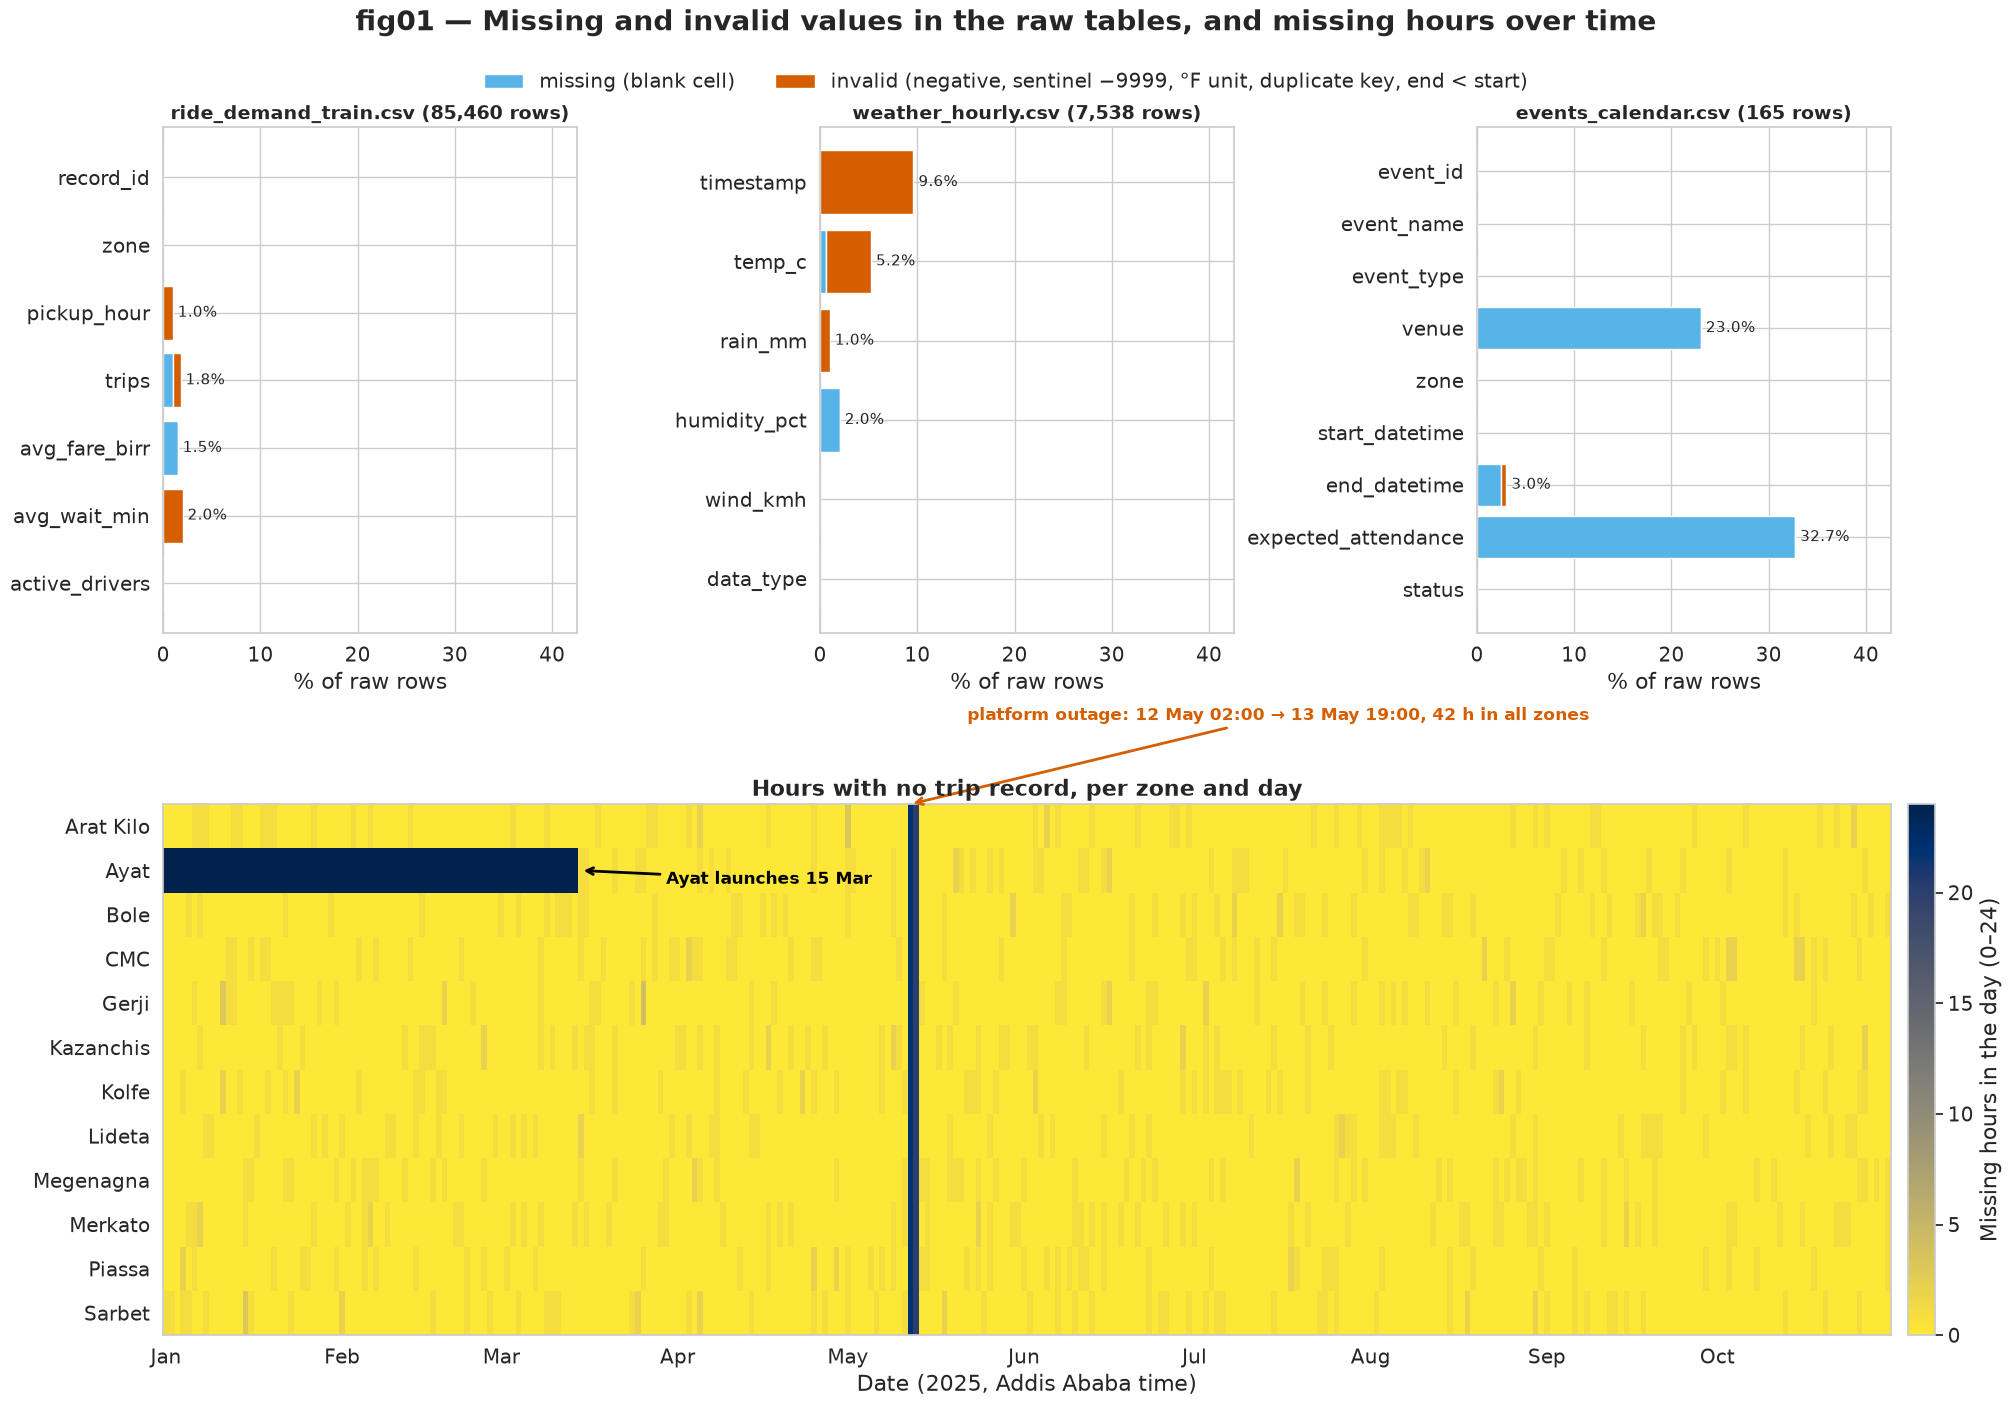

saved fig01_gaps_and_missingness.png: 3016×2110px


,table,column,missing_pct,invalid_pct,total_pct
0,ride_demand_train.csv,record_id,0.00,0.00,0.00
1,ride_demand_train.csv,zone,0.00,0.00,0.00
2,ride_demand_train.csv,pickup_hour,0.00,0.99,0.99
3,ride_demand_train.csv,trips,0.99,0.80,1.79
4,ride_demand_train.csv,avg_fare_birr,1.49,0.00,1.49
5,ride_demand_train.csv,avg_wait_min,0.00,2.00,2.00
6,ride_demand_train.csv,active_drivers,0.00,0.00,0.00
7,weather_hourly.csv,timestamp,0.00,9.60,9.60
8,weather_hourly.csv,temp_c,0.56,4.68,5.24
9,weather_hourly.csv,rain_mm,0.00,1.01,1.01


In [2]:
raw_trips = load_raw_trips("train")
raw_weather = load_raw_weather()
raw_events = load_raw_events()

trip_ts = parse_trip_hour(raw_trips["pickup_hour"])
trip_dup = pd.DataFrame(
    {"zone": raw_trips["zone"].map(normalize_zone_label), "hour": trip_ts.dt.floor("h")}
).duplicated(keep="first")
wx_ts = parse_weather_timestamp(raw_weather["timestamp"])
ev_start = parse_event_datetime(raw_events["start_datetime"])
ev_end = parse_event_datetime(raw_events["end_datetime"])

tables = {
    "ride_demand_train.csv": raw_trips,
    "weather_hourly.csv": raw_weather,
    "events_calendar.csv": raw_events,
}
invalid = {
    "ride_demand_train.csv": {
        "trips": raw_trips["trips"] < 0,
        "avg_wait_min": raw_trips["avg_wait_min"] < 0,
        "pickup_hour": trip_ts.isna() | trip_dup,
    },
    "weather_hourly.csv": {
        "rain_mm": raw_weather["rain_mm"] == -9999,
        "temp_c": raw_weather["temp_c"].between(50, 80),
        "timestamp": wx_ts.isna() | wx_ts.dt.floor("h").duplicated(keep="first"),
    },
    "events_calendar.csv": {
        "start_datetime": ev_start.isna(),
        "end_datetime": ev_end < ev_start,
    },
}
rows = []
for tname, df in tables.items():
    for col in df.columns:
        bad = invalid[tname].get(col)
        rows.append(
            {
                "table": tname,
                "column": col,
                "missing_pct": 100 * df[col].isna().mean(),
                "invalid_pct": 100 * bad.mean() if bad is not None else 0.0,
            }
        )
issues = pd.DataFrame(rows)
issues["total_pct"] = issues["missing_pct"] + issues["invalid_pct"]

# zone × day timeline of hours with no record at all
hours = pd.date_range(master["pickup_hour_eat"].min(), master["pickup_hour_eat"].max(), freq="h")
present = (
    master.assign(p=1)
    .pivot_table(index="pickup_hour_eat", columns="zone", values="p", aggfunc="max")
    .reindex(index=hours, columns=CANONICAL_ZONES)
    .fillna(0)
)
absent = 1 - present
missing_daily = absent.groupby(absent.index.floor("D")).sum().T
zones_missing = absent.sum(axis=1)
outage_hours = zones_missing.index[zones_missing >= 10]
ayat_launch = master.loc[master["zone"] == "Ayat", "pickup_hour_eat"].min()

fig = plt.figure(figsize=(20, 13), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.05])
xmax = issues["total_pct"].max() * 1.3
for i, (tname, df) in enumerate(tables.items()):
    ax = fig.add_subplot(gs[0, i])
    sub = issues[issues["table"] == tname].iloc[::-1]
    y = np.arange(len(sub))
    ax.barh(y, sub["missing_pct"], color=C["sky"], label="missing (blank cell)")
    ax.barh(
        y, sub["invalid_pct"], left=sub["missing_pct"], color=C["vermillion"],
        label="invalid (negative, sentinel −9999, °F unit, duplicate key, end < start)",
    )
    for yy, tot in zip(y, sub["total_pct"]):
        if tot > 0:
            ax.text(tot, yy, f" {tot:.1f}%", va="center", fontsize=11)
    ax.set_yticks(y, sub["column"])
    ax.set_xlim(0, xmax)
    ax.set_xlabel("% of raw rows")
    ax.set_title(f"{tname} ({len(df):,} rows)", fontsize=14)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.035), ncol=2, frameon=False)

ax = fig.add_subplot(gs[1, :])
days = missing_daily.columns
im = ax.imshow(missing_daily.to_numpy(), aspect="auto", cmap="cividis_r", vmin=0, vmax=24, interpolation="nearest")
month_idx = [i for i, d in enumerate(days) if d.day == 1]
ax.set_xticks(month_idx, [days[i].strftime("%b") for i in month_idx])
ax.set_yticks(range(len(CANONICAL_ZONES)), CANONICAL_ZONES)
ax.grid(False)
ax.set_xlabel("Date (2025, Addis Ababa time)")
ax.set_title("Hours with no trip record, per zone and day")
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label("Missing hours in the day (0–24)")

outage_days = sorted(set(outage_hours.floor("D")))
x = days.get_loc(outage_days[0])
ax.annotate(
    f"platform outage: {outage_hours.min():%d %b %H:%M} → {outage_hours.max():%d %b %H:%M}, "
    f"{len(outage_hours)} h in all zones",
    xy=(x, -0.5), xytext=(x + 10, -2.4), fontsize=12, color=C["vermillion"], fontweight="bold",
    annotation_clip=False, arrowprops=dict(arrowstyle="->", color=C["vermillion"], lw=2),
)
ayat_row = CANONICAL_ZONES.index("Ayat")
ax.annotate(
    f"Ayat launches {ayat_launch:%d %b}", xy=(days.get_loc(ayat_launch.floor("D")), ayat_row),
    xytext=(days.get_loc(ayat_launch.floor("D")) + 15, ayat_row + 0.2), fontsize=12, fontweight="bold",
    color=C["black"], va="center", arrowprops=dict(arrowstyle="->", color=C["black"], lw=2),
)
fig.suptitle("fig01 — Missing and invalid values in the raw tables, and missing hours over time", y=1.07)
save(fig, "fig01_gaps_and_missingness")

worst = issues.sort_values("total_pct", ascending=False).iloc[0]
captions["fig01_gaps_and_missingness"] = (
    f"Data problems are concentrated in a few columns. The worst is `{worst.column}` in {worst.table} "
    f"({worst.total_pct:.1f}% of rows), and every other trip-table column is below "
    f"{issues.loc[issues.table == 'ride_demand_train.csv', 'total_pct'].max():.1f}%. The timeline separates three kinds of gap: "
    f"one platform outage ({len(outage_hours)} h on {', '.join(f'{d:%d %b}' for d in outage_days)}) hitting every zone, "
    f"Ayat having no rows until it launched on {ayat_launch:%d %b}, and scattered single missing hours. "
    "None of these gaps are filled with zero demand."
)
issues.round(2)

## fig02 — Before vs after cleaning

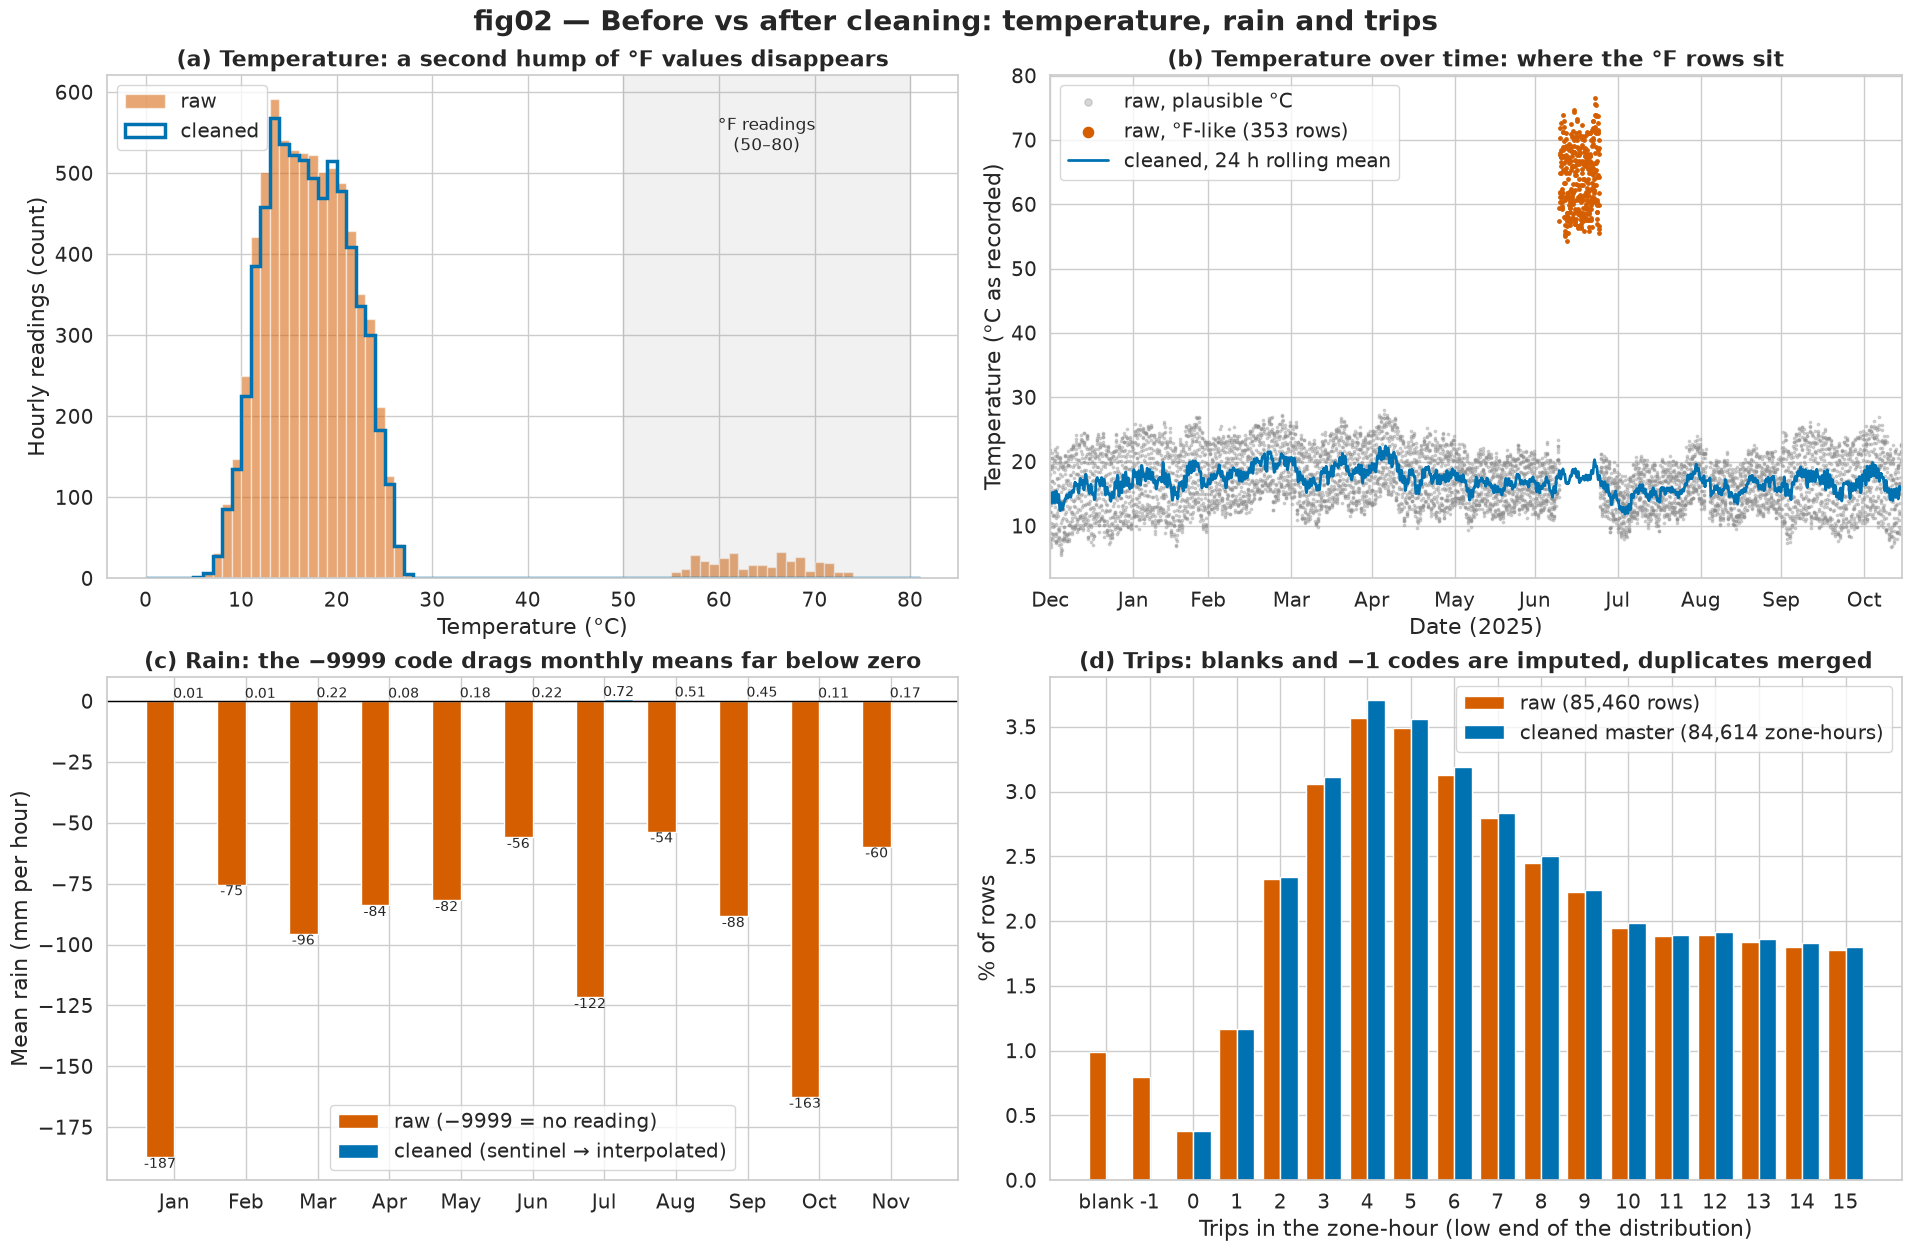

saved fig02_before_after_cleaning.png: 2867×1877px


In [3]:
w_raw = raw_weather.assign(ts=wx_ts).dropna(subset=["ts"])
f_mask = w_raw["temp_c"].between(50, 80)

fig, axes = plt.subplots(2, 2, figsize=(19, 12), constrained_layout=True)

ax = axes[0, 0]
bins = np.arange(0, 82, 1)
ax.hist(w_raw["temp_c"].dropna(), bins=bins, color=C["vermillion"], alpha=0.55, label="raw")
ax.hist(weather_clean["temp_c"], bins=bins, histtype="step", lw=2.5, color=C["blue"], label="cleaned")
ax.axvspan(50, 80, color=C["grey"], alpha=0.12)
ax.text(65, ax.get_ylim()[1] * 0.85, "°F readings\n(50–80)", ha="center", fontsize=12)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Hourly readings (count)")
ax.set_title("(a) Temperature: a second hump of °F values disappears")
ax.legend()

ax = axes[0, 1]
ax.scatter(w_raw.loc[~f_mask, "ts"], w_raw.loc[~f_mask, "temp_c"], s=3, color=C["grey"], alpha=0.35, label="raw, plausible °C")
ax.scatter(w_raw.loc[f_mask, "ts"], w_raw.loc[f_mask, "temp_c"], s=6, color=C["vermillion"], label=f"raw, °F-like ({f_mask.sum()} rows)")
ax.plot(
    weather_clean["timestamp_eat"], weather_clean["temp_c"].rolling(24, center=True).mean(),
    color=C["blue"], lw=2, label="cleaned, 24 h rolling mean",
)
ax.set_xlim(pd.Timestamp("2025-01-01", tz="Africa/Addis_Ababa"), weather_clean["timestamp_eat"].max())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_ylabel("Temperature (°C as recorded)")
ax.set_xlabel("Date (2025)")
ax.set_title("(b) Temperature over time: where the °F rows sit")
ax.legend(markerscale=3, loc="upper left")

ax = axes[1, 0]
months = range(1, 12)
rain_raw_m = w_raw.groupby(w_raw["ts"].dt.month)["rain_mm"].mean().reindex(months)
rain_clean_m = weather_clean.groupby(weather_clean["timestamp_eat"].dt.month)["rain_mm"].mean().reindex(months)
x = np.arange(len(months))
ax.bar(x - 0.2, rain_raw_m, width=0.4, color=C["vermillion"], label="raw (−9999 = no reading)")
ax.bar(x + 0.2, rain_clean_m, width=0.4, color=C["blue"], label="cleaned (sentinel → interpolated)")
for xi, (r, c) in enumerate(zip(rain_raw_m, rain_clean_m)):
    if r < -1:
        ax.text(xi - 0.2, r, f"{r:.0f}", ha="center", va="top", fontsize=10)
    ax.text(xi + 0.2, max(c, 0), f"{c:.2f}", ha="center", va="bottom", fontsize=10)
ax.axhline(0, color=C["black"], lw=1)
ax.set_xticks(x, [pd.Timestamp(2025, m, 1).strftime("%b") for m in months])
ax.set_ylabel("Mean rain (mm per hour)")
ax.set_title("(c) Rain: the −9999 code drags monthly means far below zero")
ax.legend(loc="lower center")

ax = axes[1, 1]
vals = list(range(-1, 16))
cats = ["blank"] + [str(v) for v in vals]
raw_share = [100 * raw_trips["trips"].isna().mean()] + [100 * (raw_trips["trips"] == v).mean() for v in vals]
clean_trips = master["trips"].round()
clean_share = [100 * master["trips"].isna().mean()] + [100 * (clean_trips == v).mean() for v in vals]
x = np.arange(len(cats))
ax.bar(x - 0.2, raw_share, width=0.4, color=C["vermillion"], label=f"raw ({len(raw_trips):,} rows)")
ax.bar(x + 0.2, clean_share, width=0.4, color=C["blue"], label=f"cleaned master ({len(master):,} zone-hours)")
ax.set_xticks(x, cats)
ax.set_xlabel("Trips in the zone-hour (low end of the distribution)")
ax.set_ylabel("% of rows")
ax.set_title("(d) Trips: blanks and −1 codes are imputed, duplicates merged")
ax.legend()

fig.suptitle("fig02 — Before vs after cleaning: temperature, rain and trips", y=1.03)
save(fig, "fig02_before_after_cleaning")

raw_neg = 100 * (raw_trips["trips"] < 0).mean()
raw_blank = 100 * raw_trips["trips"].isna().mean()
captions["fig02_before_after_cleaning"] = (
    f"Cleaning changes the picture for three variables. {f_mask.sum()} temperature readings in the 50–80 range were Fahrenheit and become °C; "
    f"{(raw_weather['rain_mm'] == -9999).sum()} rain readings coded −9999 pulled monthly mean rain as low as "
    f"{rain_raw_m.min():.0f} mm/h and are interpolated instead; {raw_blank:.1f}% blank and {raw_neg:.1f}% negative (−1) trip counts are imputed. "
    "Without these fixes the rain and temperature features would be meaningless."
)

## fig03 — City-wide demand trend with public holidays

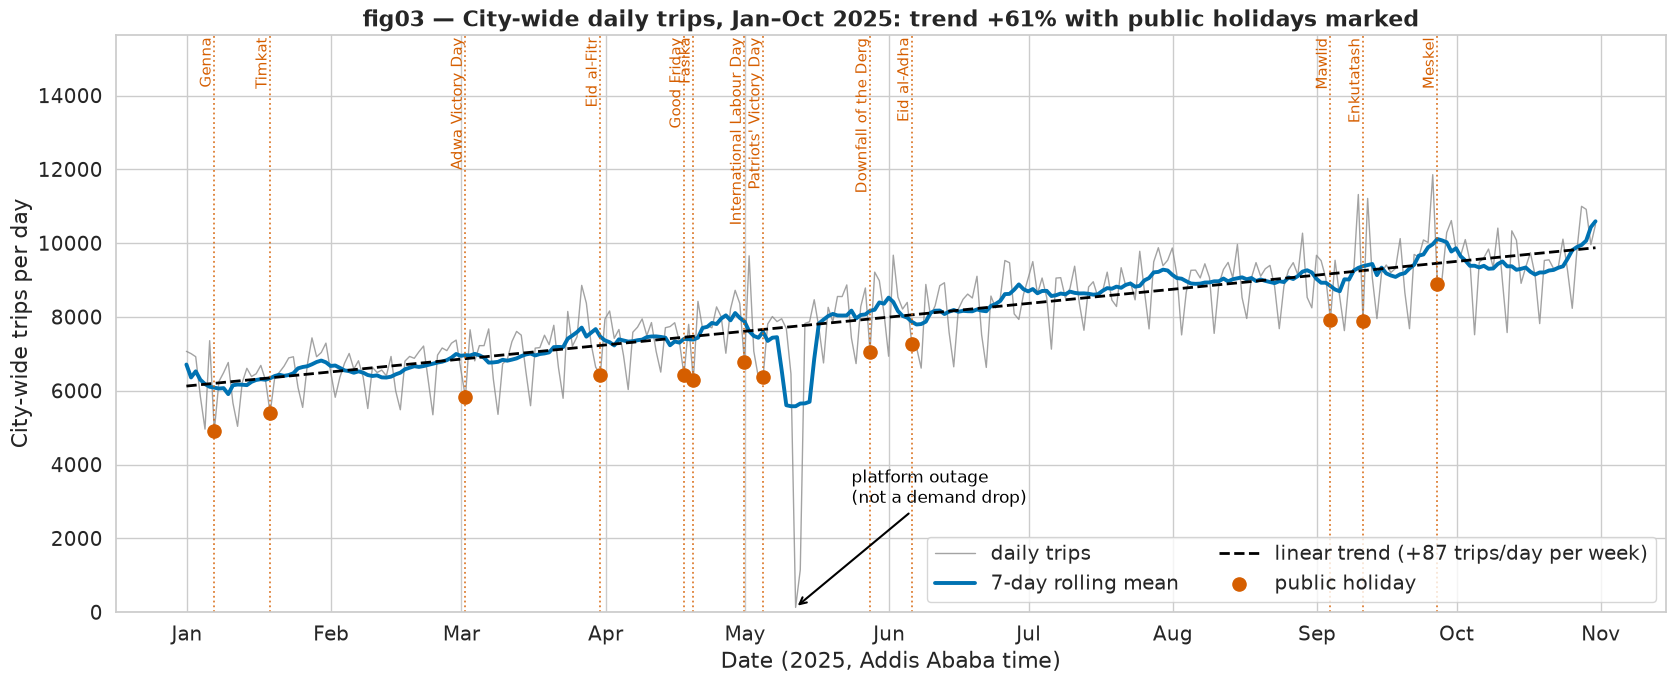

saved fig03_demand_trend_with_holidays.png: 2510×1024px


In [4]:
daily = master.groupby("day").agg(trips=("trips", "sum")).reset_index()
daily["roll7"] = daily["trips"].rolling(7, center=True, min_periods=4).mean()
t = (daily["day"] - daily["day"].min()).dt.days.to_numpy()
coef = np.polyfit(t, daily["trips"], 1)
daily["trend"] = np.polyval(coef, t)
growth = 100 * (daily["trend"].iloc[-1] / daily["trend"].iloc[0] - 1)

fig, ax = plt.subplots(figsize=(20, 7.5))
ax.plot(daily["day"], daily["trips"], color=C["grey"], lw=1, alpha=0.8, label="daily trips")
ax.plot(daily["day"], daily["roll7"], color=C["blue"], lw=2.8, label="7-day rolling mean")
ax.plot(daily["day"], daily["trend"], color=C["black"], lw=2, ls="--", label=f"linear trend (+{coef[0] * 7:,.0f} trips/day per week)")
hol_in = holidays[holidays["day"].isin(daily["day"])].sort_values("day")
hol_trips = daily.set_index("day").loc[hol_in["day"], "trips"]
ax.scatter(hol_in["day"], hol_trips, s=90, color=C["vermillion"], zorder=5, label="public holiday")
ymax = daily["trips"].max() * 1.32
for _, h in hol_in.iterrows():
    ax.axvline(h["day"], color=C["vermillion"], ls=":", lw=1.3, alpha=0.8)
    ax.text(h["day"], ymax * 0.995, " " + h["event_name"].split(" (")[0], rotation=90, va="top", ha="right", fontsize=11, color=C["vermillion"])
low_day = daily.loc[daily["trips"].idxmin()]
ax.annotate(
    "platform outage\n(not a demand drop)", xy=(low_day["day"], low_day["trips"]),
    xytext=(low_day["day"] + pd.Timedelta(days=12), daily["trips"].max() * 0.25),
    fontsize=12, color=C["black"], arrowprops=dict(arrowstyle="->", color=C["black"], lw=1.5),
)
ax.set_ylim(0, ymax)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlabel("Date (2025, Addis Ababa time)")
ax.set_ylabel("City-wide trips per day")
ax.set_title(f"fig03 — City-wide daily trips, Jan–Oct 2025: trend +{growth:.0f}% with public holidays marked")
ax.legend(loc="lower right", ncol=2)
save(fig, "fig03_demand_trend_with_holidays")

hol_low = (hol_trips < daily.set_index("day").loc[hol_in["day"], "roll7"]).sum()
captions["fig03_demand_trend_with_holidays"] = (
    f"City demand grows steadily through the year: the linear trend rises {growth:.0f}% from January to October "
    f"(about {coef[0] * 7:,.0f} more trips per day each week), so a November forecast needs a trend or recent-level term. "
    f"{hol_low} of the {len(hol_in)} public holidays fall below their 7-day mean, so holidays matter too, but they are short dips "
    "on top of the trend rather than a change in it."
)

## fig04 — Hour × weekday heatmaps

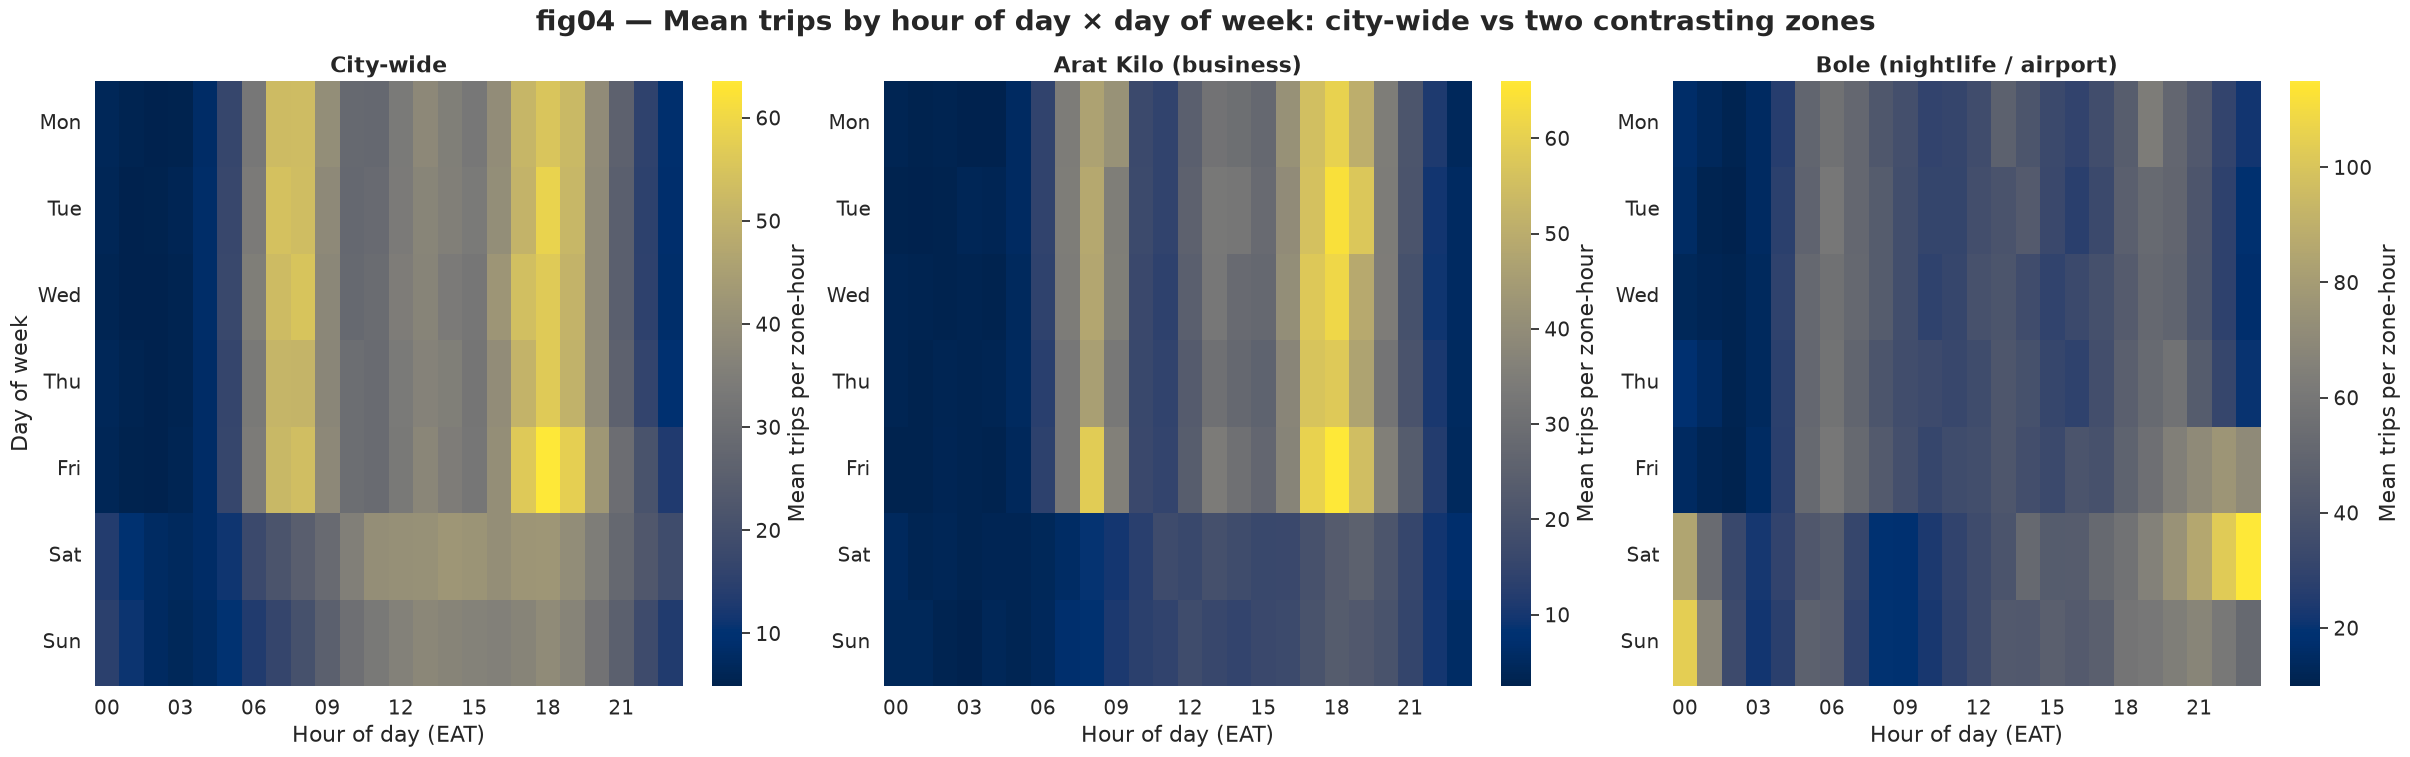

saved fig04_hour_by_weekday_heatmap.png: 3615×1136px


In [5]:
def hour_dow(df: pd.DataFrame) -> pd.DataFrame:
    return df.pivot_table(index="dow", columns="hour", values="trips", aggfunc="mean").reindex(range(7))


panels = [
    ("City-wide", master),
    ("Arat Kilo (business)", master[master["zone"] == "Arat Kilo"]),
    ("Bole (nightlife / airport)", master[master["zone"] == "Bole"]),
]
fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)
grids = {}
for ax, (title, df) in zip(axes, panels):
    hm = hour_dow(df)
    grids[title] = hm
    sns.heatmap(hm, ax=ax, cmap="cividis", cbar_kws={"label": "Mean trips per zone-hour"})
    ax.set_yticks(np.arange(7) + 0.5, DOW, rotation=0)
    ax.set_xticks(np.arange(0, 24, 3) + 0.5, [f"{h:02d}" for h in range(0, 24, 3)], rotation=0)
    ax.set_xlabel("Hour of day (EAT)")
    ax.set_ylabel("")
    ax.set_title(title)
axes[0].set_ylabel("Day of week")
fig.suptitle("fig04 — Mean trips by hour of day × day of week: city-wide vs two contrasting zones", y=1.06)
save(fig, "fig04_hour_by_weekday_heatmap")


def wk_ratio(hm: pd.DataFrame) -> float:
    return hm.loc[[5, 6]].to_numpy().mean() / hm.loc[[0, 1, 2, 3, 4]].to_numpy().mean()


city = grids["City-wide"]
pk_dow, pk_hour = np.unravel_index(np.nanargmax(city.to_numpy()), city.shape)
captions["fig04_hour_by_weekday_heatmap"] = (
    f"City-wide demand peaks on {DOW[pk_dow]} at {pk_hour:02d}:00. The zones contrast sharply: Arat Kilo's weekend demand is "
    f"{wk_ratio(grids['Arat Kilo (business)']):.2f}× its weekday level, while Bole's is {wk_ratio(grids['Bole (nightlife / airport)']):.2f}×, "
    "with late-night weekend hours. A single city-wide weekly profile would be wrong for both, so the model needs zone × hour × day-of-week interactions."
)

## fig05 — Weekday and weekend profiles by zone type

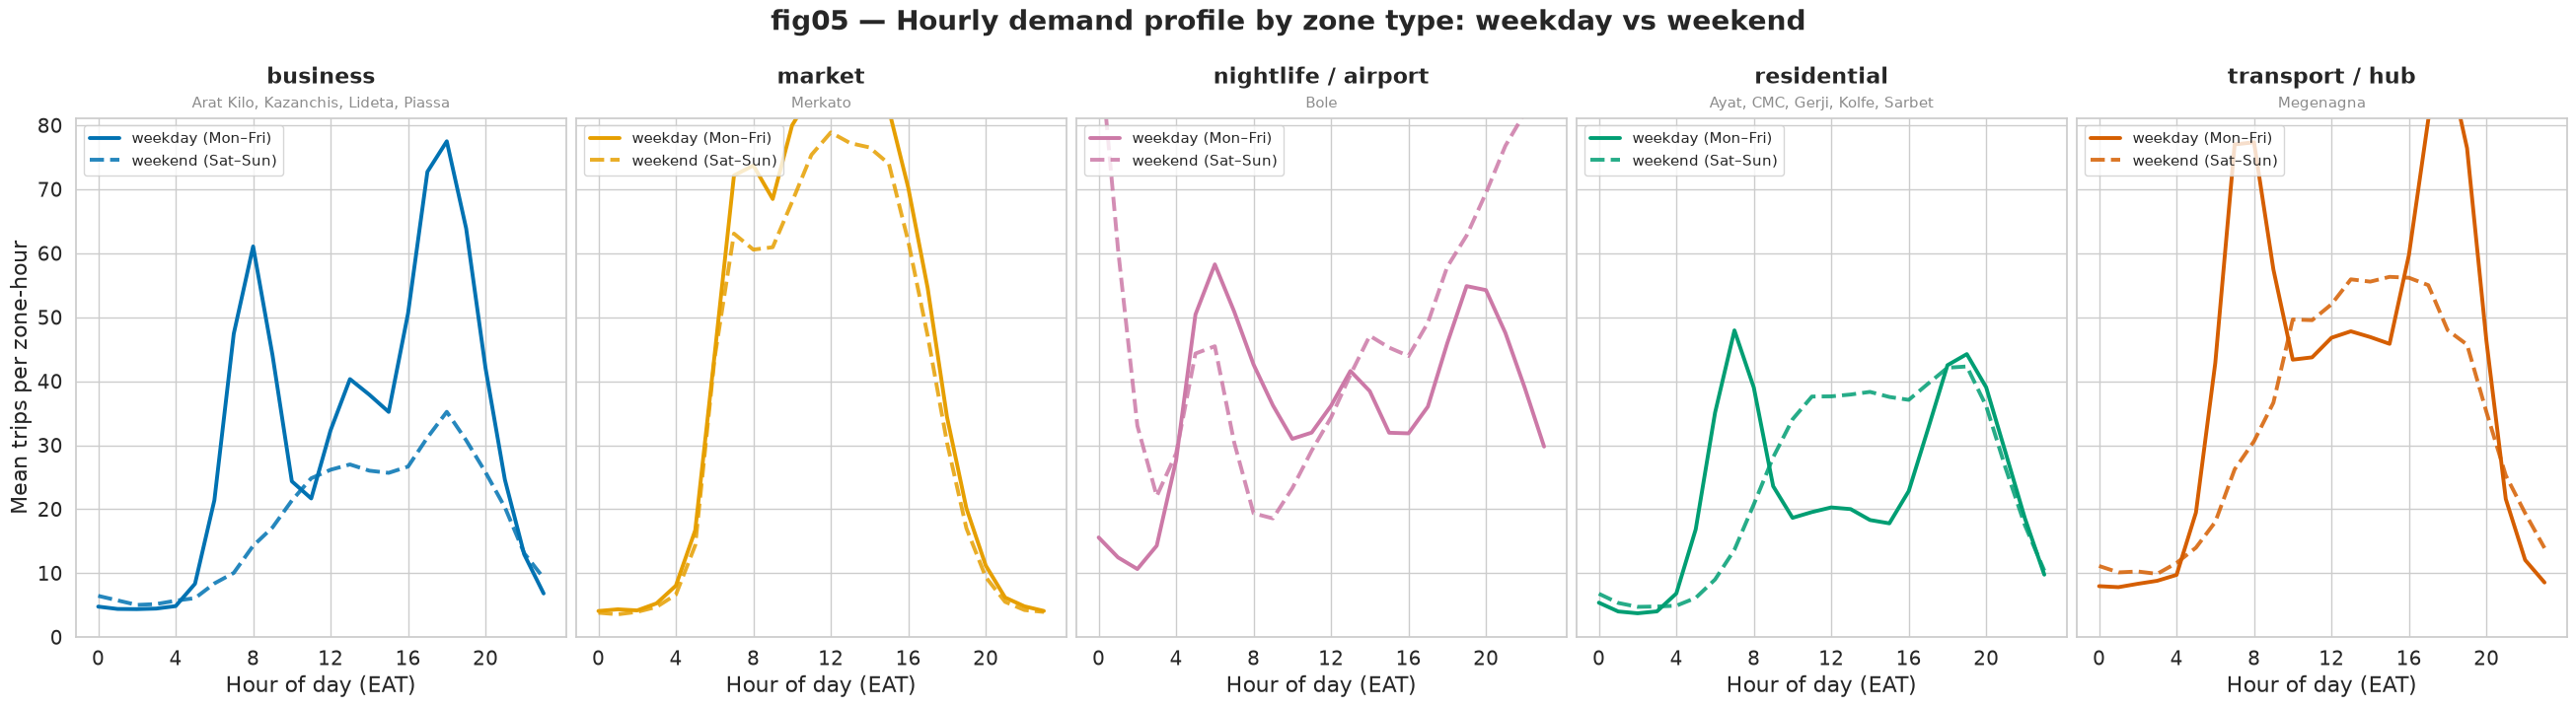

saved fig05_zone_profiles.png: 3917×1076px


In [6]:
prof = master.groupby(["zone_type", "is_weekend", "hour"])["trips"].mean()
fig, axes = plt.subplots(1, 5, figsize=(26, 6.5), sharey=True, constrained_layout=True)
peaks = {}
for ax, zt in zip(axes, TYPE_ORDER):
    for wk, ls, lab in [(0, "-", "weekday (Mon–Fri)"), (1, "--", "weekend (Sat–Sun)")]:
        s = prof.loc[(zt, wk)]
        ax.plot(s.index, s.values, ls=ls, lw=2.8, color=TYPE_COLOR[zt], alpha=1 if wk == 0 else 0.85, label=lab)
        peaks[(zt, wk)] = int(s.idxmax())
    zones = ", ".join(sorted(z for z, t in ZONE_TYPE.items() if t == zt))
    ax.set_title(f"{zt.replace('_', ' / ')}\n", fontsize=16)
    ax.text(0.5, 1.02, zones, transform=ax.transAxes, ha="center", fontsize=11, color=C["grey"])
    ax.set_xticks(range(0, 24, 4))
    ax.set_xlabel("Hour of day (EAT)")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=11, loc="upper left")
axes[0].set_ylabel("Mean trips per zone-hour")
fig.suptitle("fig05 — Hourly demand profile by zone type: weekday vs weekend", y=1.08)
save(fig, "fig05_zone_profiles")

captions["fig05_zone_profiles"] = (
    "Each zone type has its own daily shape. Weekday peaks fall at "
    + ", ".join(f"{zt.replace('_', '/')} {peaks[(zt, 0)]:02d}:00" for zt in TYPE_ORDER)
    + ". At weekends, business zones flatten while the nightlife/airport zone keeps its demand into the night, "
    "which is why zone type (or zone) has to interact with hour and weekend in the model."
)

## fig06 — Weather clock (time-zone) check

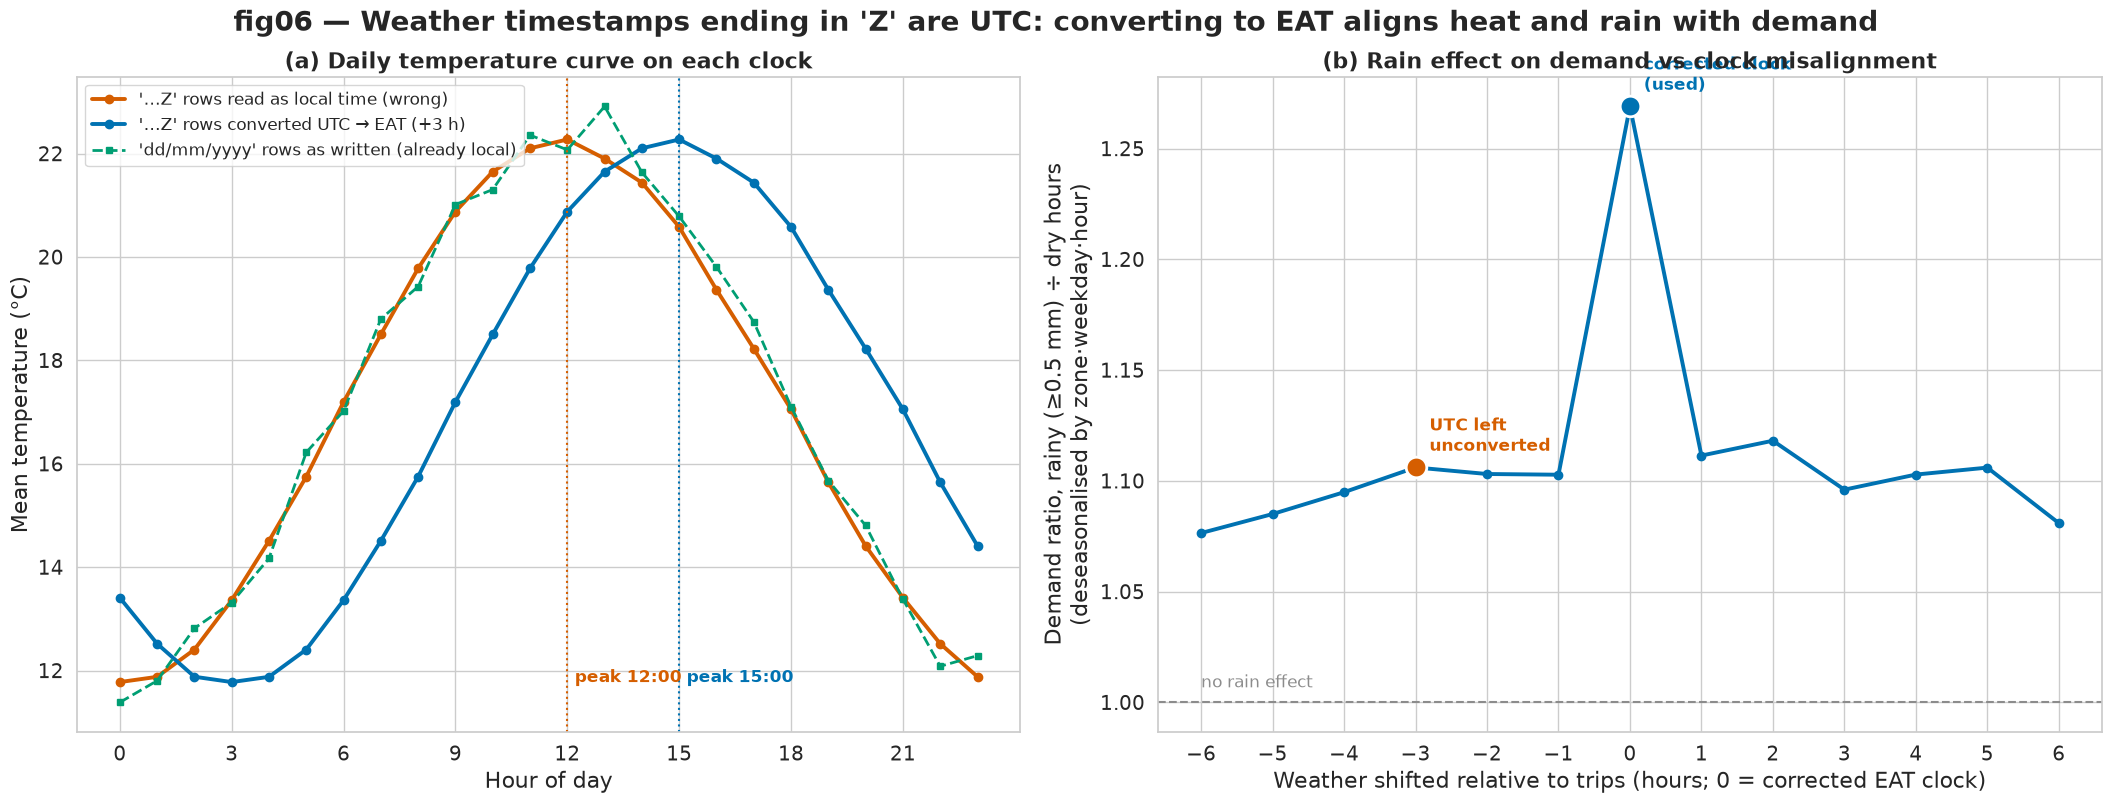

saved fig06_weather_timezone_check.png: 3167×1204px


,rain_uplift,corr
shift_h,,
-6,1.076,0.036
-5,1.085,0.038
-4,1.095,0.040
-3,1.106,0.041
-2,1.103,0.044
-1,1.103,0.048
0,1.269,0.161
1,1.111,0.048
2,1.118,0.056


In [7]:
w = raw_weather.copy()
w["temp_fixed"] = np.where(w["temp_c"].between(50, 80), (w["temp_c"] - 32) * 5 / 9, w["temp_c"])
ts_str = w["timestamp"].astype(str)
z_rows = w[ts_str.str.endswith("Z")].copy()
z_naive = pd.to_datetime(z_rows["timestamp"].str.rstrip("Z"))
z_rows["hour_as_written"] = z_naive.dt.hour
z_rows["hour_eat"] = (z_naive + pd.Timedelta(hours=3)).dt.hour
s_rows = w[ts_str.str.contains("/")].copy()
s_rows["hour_as_written"] = pd.to_datetime(s_rows["timestamp"], format="%d/%m/%Y %H:%M").dt.hour

curve_written = z_rows.groupby("hour_as_written")["temp_fixed"].mean()
curve_eat = z_rows.groupby("hour_eat")["temp_fixed"].mean()
curve_slash = s_rows.groupby("hour_as_written")["temp_fixed"].mean()

# rain–demand signal when weather is shifted against trips; deseasonalised by zone·dow·hour
base = master.loc[master["in_event_window"] == 0].groupby(["zone", "dow", "hour"])["trips"].mean().rename("base")
d6 = master.join(base, on=["zone", "dow", "hour"])
d6 = d6[d6["base"] > 0].assign(ratio=lambda x: x["trips"] / x["base"])[["pickup_hour_eat", "ratio"]]
wx = weather_clean[["timestamp_eat", "rain_mm"]].rename(columns={"timestamp_eat": "pickup_hour_eat"})
shift_rows = []
for shift in range(-6, 7):
    tmp = d6.merge(wx.assign(pickup_hour_eat=wx["pickup_hour_eat"] + pd.Timedelta(hours=shift)), on="pickup_hour_eat")
    rainy = tmp.loc[tmp["rain_mm"] >= 0.5, "ratio"].mean()
    dry = tmp.loc[tmp["rain_mm"] <= 0, "ratio"].mean()
    shift_rows.append({"shift_h": shift, "rain_uplift": rainy / dry, "corr": tmp["ratio"].corr(tmp["rain_mm"])})
shifts = pd.DataFrame(shift_rows).set_index("shift_h")

fig, axes = plt.subplots(1, 2, figsize=(21, 7.5), constrained_layout=True)
ax = axes[0]
ax.plot(curve_written.index, curve_written.values, color=C["vermillion"], lw=2.8, marker="o", label="'…Z' rows read as local time (wrong)")
ax.plot(curve_eat.index, curve_eat.values, color=C["blue"], lw=2.8, marker="o", label="'…Z' rows converted UTC → EAT (+3 h)")
ax.plot(curve_slash.index, curve_slash.values, color=C["green"], lw=2, ls="--", marker="s", ms=5, label="'dd/mm/yyyy' rows as written (already local)")
for curve, col in [(curve_written, C["vermillion"]), (curve_eat, C["blue"])]:
    ax.axvline(curve.idxmax(), color=col, ls=":", lw=1.5)
    ax.text(curve.idxmax() + 0.2, curve.min(), f"peak {curve.idxmax():02d}:00", color=col, fontsize=12, fontweight="bold")
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean temperature (°C)")
ax.set_title("(a) Daily temperature curve on each clock")
ax.legend(loc="upper left", fontsize=12)

ax = axes[1]
ax.plot(shifts.index, shifts["rain_uplift"], color=C["blue"], lw=2.8, marker="o")
ax.axhline(1, color=C["grey"], ls="--", lw=1.5)
ax.text(-6, 1.005, "no rain effect", color=C["grey"], fontsize=12, va="bottom")
for s, lab, col in [(0, "corrected clock\n(used)", C["blue"]), (-3, "UTC left\nunconverted", C["vermillion"])]:
    ax.scatter([s], [shifts.loc[s, "rain_uplift"]], s=220, color=col, zorder=5, edgecolor="white", lw=2)
    ax.annotate(lab, (s, shifts.loc[s, "rain_uplift"]), xytext=(10, 12), textcoords="offset points", color=col, fontsize=12, fontweight="bold")
ax.set_xticks(range(-6, 7))
ax.set_xlabel("Weather shifted relative to trips (hours; 0 = corrected EAT clock)")
ax.set_ylabel("Demand ratio, rainy (≥0.5 mm) ÷ dry hours\n(deseasonalised by zone·weekday·hour)")
ax.set_title("(b) Rain effect on demand vs clock misalignment")
fig.suptitle("fig06 — Weather timestamps ending in 'Z' are UTC: converting to EAT aligns heat and rain with demand", y=1.05)
save(fig, "fig06_weather_timezone_check")

captions["fig06_weather_timezone_check"] = (
    f"Weather timestamps ending in 'Z' are UTC. Read as local time, temperature would peak at {curve_written.idxmax():02d}:00; "
    f"after the +3 h conversion it peaks at {curve_eat.idxmax():02d}:00, matching the slash-format rows (already local, peak {curve_slash.idxmax():02d}:00). "
    f"The rain effect on demand is strongest on the corrected clock (×{shifts.loc[0, 'rain_uplift']:.2f}) and drops to "
    f"×{shifts.loc[-3, 'rain_uplift']:.2f} if UTC is left unconverted, so the conversion directly protects the rain features."
)
shifts.round(3)

## fig07 — Rain effect by rain class and zone type

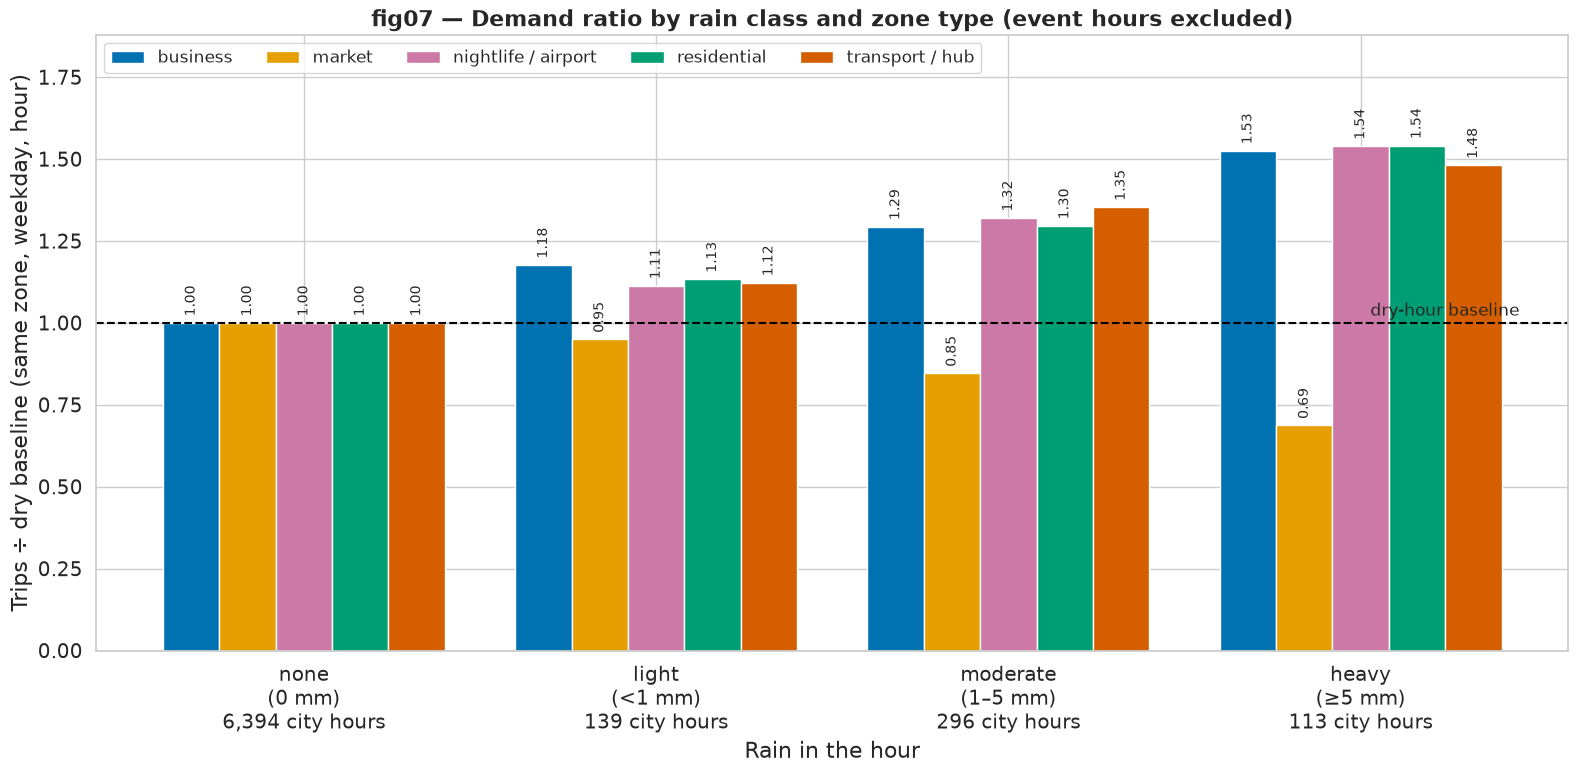

saved fig07_rain_effect.png: 2366×1160px


rain_class,0,1,2,3
zone_type,,,,
business,1.0,1.176,1.294,1.525
market,1.0,0.950,0.846,0.687
nightlife_airport,1.0,1.113,1.320,1.539
residential,1.0,1.133,1.296,1.541
transport_hub,1.0,1.122,1.353,1.481


In [8]:
no_ev = master[master["in_event_window"] == 0]
dry_base = no_ev[no_ev["rain_mm"] <= 0].groupby(["zone", "dow", "hour"])["trips"].mean().rename("dry_base")
d7 = no_ev.join(dry_base, on=["zone", "dow", "hour"]).dropna(subset=["dry_base"])
d7 = d7[d7["dry_base"] > 0]
sums = d7.groupby(["zone_type", "rain_class"])[["trips", "dry_base"]].sum()
ratio7 = (sums["trips"] / sums["dry_base"]).unstack("rain_class").reindex(index=TYPE_ORDER, columns=[0, 1, 2, 3])
city_hours = d7.drop_duplicates("pickup_hour_eat")["rain_class"].value_counts().reindex([0, 1, 2, 3]).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(19, 8))
x = np.arange(4)
width = 0.16
for i, zt in enumerate(TYPE_ORDER):
    xs = x + (i - 2) * width
    ax.bar(xs, ratio7.loc[zt], width=width, color=TYPE_COLOR[zt], label=zt.replace("_", " / "))
    for xx, v in zip(xs, ratio7.loc[zt]):
        ax.text(xx, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=10, rotation=90)
ax.axhline(1, color=C["black"], ls="--", lw=1.5)
ax.text(3.45, 1.01, "dry-hour baseline", ha="right", va="bottom", fontsize=12)
ax.set_xticks(x, [f"{lab}\n{n:,} city hours" for lab, n in zip(RAIN_LABELS, city_hours)])
ax.set_ylim(0, np.nanmax(ratio7.to_numpy()) * 1.22)
ax.set_xlabel("Rain in the hour")
ax.set_ylabel("Trips ÷ dry baseline (same zone, weekday, hour)")
ax.set_title("fig07 — Demand ratio by rain class and zone type (event hours excluded)")
ax.legend(ncol=5, loc="upper left", fontsize=12)
save(fig, "fig07_rain_effect")

heavy = ratio7[3].dropna().sort_values()
captions["fig07_rain_effect"] = (
    f"Rain increases demand and the effect grows with intensity, but not equally across zone types: "
    f"in heavy rain the uplift ranges from ×{heavy.iloc[0]:.2f} ({heavy.index[0].replace('_', '/')}) to ×{heavy.iloc[-1]:.2f} ({heavy.index[-1].replace('_', '/')}). "
    f"Heavy-rain hours are rare ({city_hours[3]} city hours), so a rain-class × zone-type interaction should be learned with regularisation."
)
ratio7.round(3)

## fig08 — Event study around event start

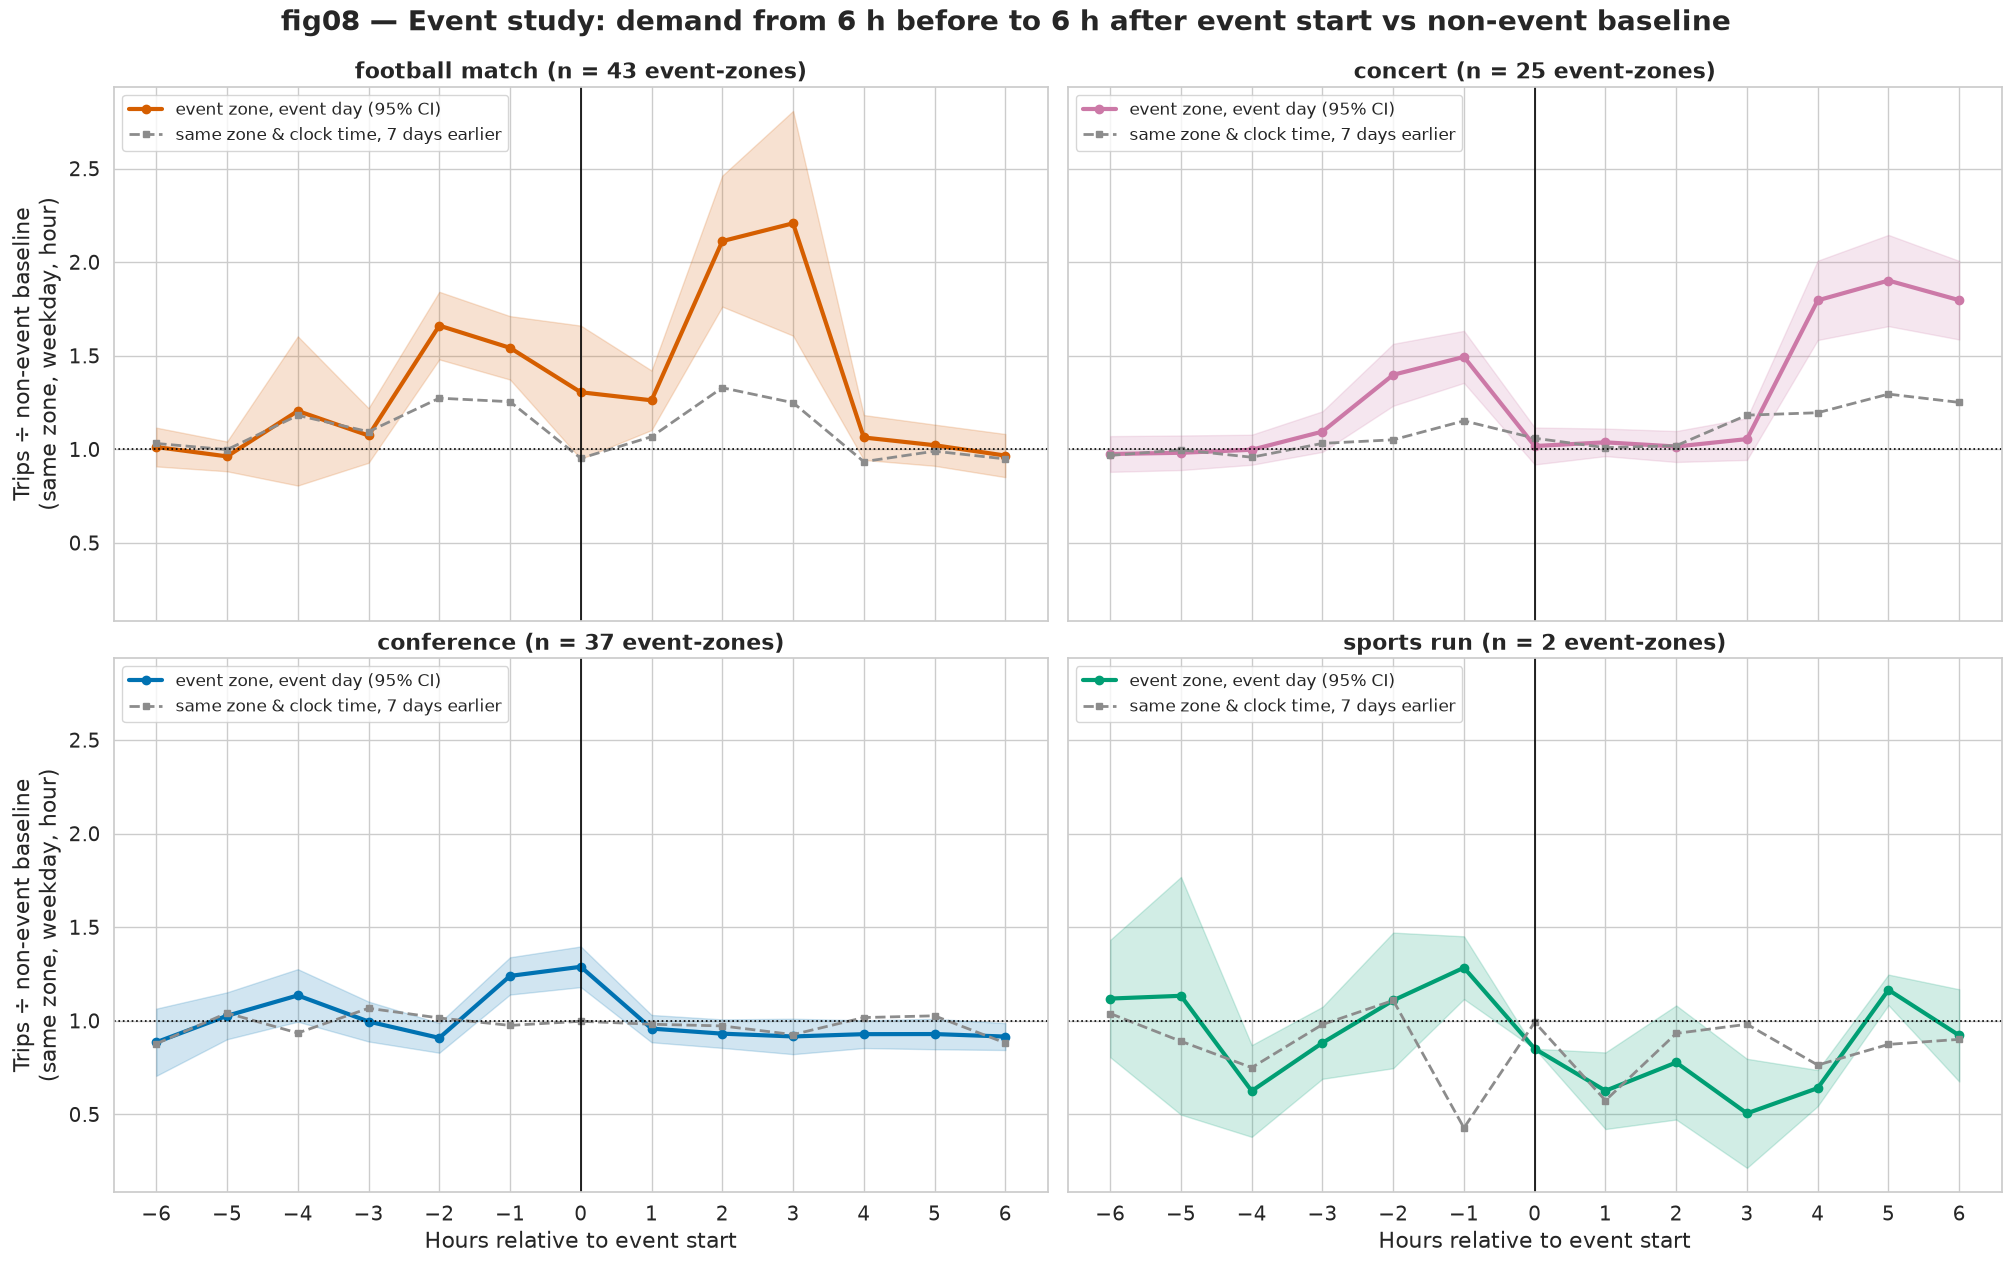

saved fig08_event_study.png: 3017×1895px


In [9]:
lookup = master.set_index(["zone", "pickup_hour_eat"])["trips"]
lookup = lookup[~lookup.index.duplicated()]
nb_base = master.loc[master["in_event_window"] == 0].groupby(["zone", "dow", "hour"])["trips"].mean()
STUDY_TYPES = ["football_match", "concert", "conference", "sports_run"]
REL = range(-6, 7)
train_end = master["pickup_hour_eat"].max()


def event_study(evs: pd.DataFrame, offset: pd.Timedelta = pd.Timedelta(0)) -> pd.DataFrame:
    rows = []
    for ev in evs.itertuples():
        t0 = ev.start_eat.floor("h") + offset
        for k in REL:
            t = t0 + pd.Timedelta(hours=k)
            if (ev.zone, t) not in lookup.index:
                continue
            b = nb_base.get((ev.zone, t.dayofweek, t.hour), np.nan)
            if not b > 0:
                continue
            rows.append({"event": f"{ev.event_id}|{ev.zone}", "k": k, "ratio": lookup[(ev.zone, t)] / b})
    df = pd.DataFrame(rows)
    g = df.groupby("k")["ratio"]
    out = pd.DataFrame({"mean": g.mean(), "sem": g.sem(), "n": g.size()}).reindex(REL)
    out.attrs["n_events"] = df["event"].nunique()
    return out


fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharex=True, sharey=True, constrained_layout=True)
studies = {}
for ax, et, col in zip(axes.flat, STUDY_TYPES, [C["vermillion"], C["purple"], C["blue"], C["green"]]):
    evs = confirmed[(confirmed["event_type"] == et) & (confirmed["start_eat"] <= train_end)]
    st = event_study(evs)
    pl = event_study(evs, offset=pd.Timedelta(days=-7))
    studies[et] = st
    ax.fill_between(st.index, st["mean"] - 1.96 * st["sem"], st["mean"] + 1.96 * st["sem"], color=col, alpha=0.18)
    ax.plot(st.index, st["mean"], color=col, lw=3, marker="o", label="event zone, event day (95% CI)")
    ax.plot(pl.index, pl["mean"], color=C["grey"], lw=2, ls="--", marker="s", ms=5, label="same zone & clock time, 7 days earlier")
    ax.axhline(1, color=C["black"], lw=1.2, ls=":")
    ax.axvline(0, color=C["black"], lw=1.2)
    ax.set_title(f"{et.replace('_', ' ')} (n = {st.attrs['n_events']} event-zones)")
    ax.legend(loc="upper left", fontsize=12)
for ax in axes[1]:
    ax.set_xlabel("Hours relative to event start")
for ax in axes[:, 0]:
    ax.set_ylabel("Trips ÷ non-event baseline\n(same zone, weekday, hour)")
axes[0, 0].set_xticks(list(REL))
fig.suptitle("fig08 — Event study: demand from 6 h before to 6 h after event start vs non-event baseline", y=1.04)
save(fig, "fig08_event_study")

peak = {et: (int(s["mean"].idxmax()), s["mean"].max()) for et, s in studies.items()}
captions["fig08_event_study"] = (
    "Events lift demand in their own zone, but the timing differs by type. Peak uplift: "
    + "; ".join(f"{et.replace('_', ' ')} ×{v:.2f} at {k:+d} h" for et, (k, v) in peak.items())
    + ". The 7-days-earlier comparison line stays near 1, so the lift comes from the event, not the time slot. "
    "This is why the event features use a separate window per type (before / during / after) rather than one flag."
)

## fig09 — Public-holiday effects

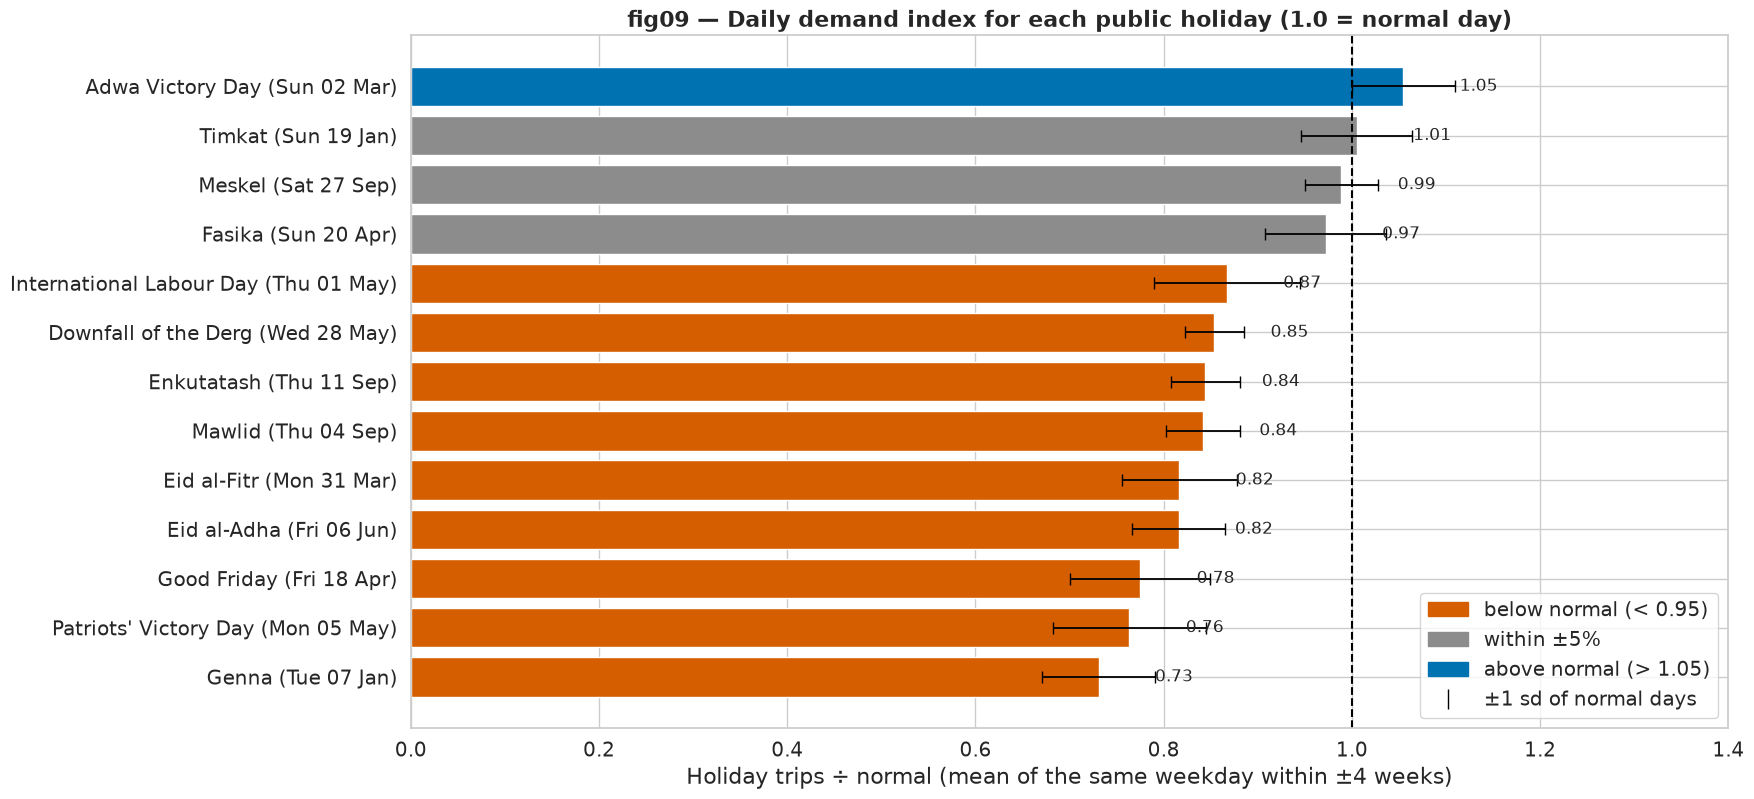

saved fig09_holiday_effects.png: 2631×1197px


,holiday,date,index,normal_sd,n_ref_days
0,Genna,2025-01-07 00:00:00+03:00,0.731,0.060,4
1,Patriots' Victory Day,2025-05-05 00:00:00+03:00,0.763,0.081,7
2,Good Friday,2025-04-18 00:00:00+03:00,0.775,0.074,8
3,Eid al-Adha,2025-06-06 00:00:00+03:00,0.816,0.049,8
4,Eid al-Fitr,2025-03-31 00:00:00+03:00,0.817,0.061,8
5,Mawlid,2025-09-04 00:00:00+03:00,0.842,0.039,7
6,Enkutatash,2025-09-11 00:00:00+03:00,0.844,0.037,7
7,Downfall of the Derg,2025-05-28 00:00:00+03:00,0.854,0.031,8
8,International Labour Day,2025-05-01 00:00:00+03:00,0.867,0.078,8
9,Fasika,2025-04-20 00:00:00+03:00,0.972,0.064,8


In [10]:
zh = master.groupby("day").agg(mean_trips=("trips", "mean"), n=("trips", "size"), zones=("zone", "nunique"))
zh["complete"] = zh["n"] >= 0.95 * zh["zones"] * 24
hol_days = set(holidays["day"])
rows = []
for h in holidays.itertuples():
    d = h.day
    if d not in zh.index:
        continue
    ref = zh[
        (zh.index.dayofweek == d.dayofweek)
        & ~zh.index.isin(hol_days)
        & zh["complete"]
        & (np.abs((zh.index - d).days) <= 28)
    ]
    rows.append(
        {
            "holiday": h.event_name.split(" (")[0],
            "date": d,
            "index": zh.loc[d, "mean_trips"] / ref["mean_trips"].mean(),
            "normal_sd": ref["mean_trips"].std() / ref["mean_trips"].mean(),
            "n_ref_days": len(ref),
        }
    )
hol_idx = pd.DataFrame(rows).sort_values("index").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(17, 9))
colors = [C["vermillion"] if v < 0.95 else C["blue"] if v > 1.05 else C["grey"] for v in hol_idx["index"]]
y = np.arange(len(hol_idx))
ax.barh(y, hol_idx["index"], color=colors, xerr=hol_idx["normal_sd"], error_kw=dict(ecolor=C["black"], capsize=4, lw=1.3))
for yy, v in zip(y, hol_idx["index"]):
    ax.text(v + 0.06, yy, f"{v:.2f}", va="center", fontsize=12)
ax.axvline(1, color=C["black"], ls="--", lw=1.5)
ax.set_yticks(y, [f"{r.holiday} ({r.date:%a %d %b})" for r in hol_idx.itertuples()])
ax.set_xlim(0, max(1.4, (hol_idx["index"] + hol_idx["normal_sd"]).max() * 1.1))
ax.set_xlabel("Holiday trips ÷ normal (mean of the same weekday within ±4 weeks)")
ax.legend(
    handles=[
        Patch(color=C["vermillion"], label="below normal (< 0.95)"),
        Patch(color=C["grey"], label="within ±5%"),
        Patch(color=C["blue"], label="above normal (> 1.05)"),
        plt.Line2D([], [], color=C["black"], marker="|", ls="", ms=14, label="±1 sd of normal days"),
    ],
    loc="lower right",
)
ax.set_title("fig09 — Daily demand index for each public holiday (1.0 = normal day)")
save(fig, "fig09_holiday_effects")

below = hol_idx[hol_idx["index"] < 0.95]
above = hol_idx[hol_idx["index"] > 1.05]
captions["fig09_holiday_effects"] = (
    f"Holidays do not all reduce demand. {len(below)} of {len(hol_idx)} fall below normal, the deepest being "
    f"{hol_idx.iloc[0].holiday} (index {hol_idx.iloc[0]['index']:.2f}); {len(above)} sit above normal "
    + (f"(highest: {hol_idx.iloc[-1].holiday}, {hol_idx.iloc[-1]['index']:.2f})" if len(above) else "")
    + ". The whiskers show ordinary day-to-day variation, so only bars that clear them are real effects. "
    "The size and direction of the effect depend on the holiday, so a holiday-specific feature would beat a single yes/no flag."
)
hol_idx.round(3)

## Models for fig10–fig12 (shared code in `src/modeling.py`)

In [11]:
table = M.build_model_table(master, history=master)
FEATS = M.ALL_FEATURES
CUTOFF = "2025-10-18"
tr, va = M.split_by_cutoff(table, CUTOFF)
print(f"train < {CUTOFF}: {len(tr):,} rows | validate {CUTOFF} + 14 days: {len(va):,} rows | {len(FEATS)} features")

BASELINES = {
    "mean baseline": M.mean_baseline,
    "seasonal naive\n(zone·dow·hour, last 4 wk)": lambda a, b: M.seasonal_naive(a, b, weeks=4),
}
MODELS = {
    "ridge": ("ridge", {}),
    "hist gradient boosting": ("hist_gbm", {}),
    "LightGBM": ("lightgbm", {}),
}

results, preds, fitted = [], {}, {}
for label, fn in BASELINES.items():
    p = fn(tr, va)
    preds[label] = p
    results.append({"model": label, "kind": "baseline", "rmse": M.rmse(va["trips"], p), "mae": M.mae(va["trips"], p), "train_s": 0.0})
for label, (name, params) in MODELS.items():
    model, p, secs = M.fit_predict(name, tr, va, FEATS, params)
    preds[label], fitted[label] = p, model
    results.append({"model": label, "kind": "model", "rmse": M.rmse(va["trips"], p), "mae": M.mae(va["trips"], p), "train_s": secs})
results = pd.DataFrame(results)
FINAL = results[results["kind"] == "model"].sort_values("rmse").iloc[0]["model"]
SNAIVE = list(BASELINES)[1]
print("final model:", FINAL)
results.round(3)

train < 2025-10-18: 80,615 rows | validate 2025-10-18 + 14 days: 3,999 rows | 33 features
final model: hist gradient boosting


,model,kind,rmse,mae,train_s
0,mean baseline,baseline,29.469,20.891,0.000
1,"seasonal naive\n(zone·dow·hour, last 4 wk)",baseline,15.525,7.231,0.000
2,ridge,model,14.934,7.504,1.116
3,hist gradient boosting,model,13.611,6.597,17.198
4,LightGBM,model,13.638,6.616,26.435


In [12]:
FOLDS = ["2025-09-06", "2025-09-20", "2025-10-04", "2025-10-18"]
name, params = MODELS[FINAL]
fold_rows = []
for cut in FOLDS:
    a, b = M.split_by_cutoff(table, cut)
    if cut == CUTOFF:
        p_final, p_snaive = preds[FINAL], preds[SNAIVE]
    else:
        _, p_final, _ = M.fit_predict(name, a, b, FEATS, params)
        p_snaive = BASELINES[SNAIVE](a, b)
    fold_rows.append({"cutoff": cut, "model": FINAL, "rmse": M.rmse(b["trips"], p_final)})
    fold_rows.append({"cutoff": cut, "model": SNAIVE, "rmse": M.rmse(b["trips"], p_snaive)})
folds = pd.DataFrame(fold_rows)
fold_stats = folds.groupby("model")["rmse"].agg(["mean", "std"])
folds.pivot(index="cutoff", columns="model", values="rmse").round(3)

model,hist gradient boosting,"seasonal naive\n(zone·dow·hour, last 4 wk)"
cutoff,,
2025-09-06,14.346,15.776
2025-09-20,13.808,16.621
2025-10-04,17.968,19.170
2025-10-18,13.611,15.525


## fig10 — Model comparison

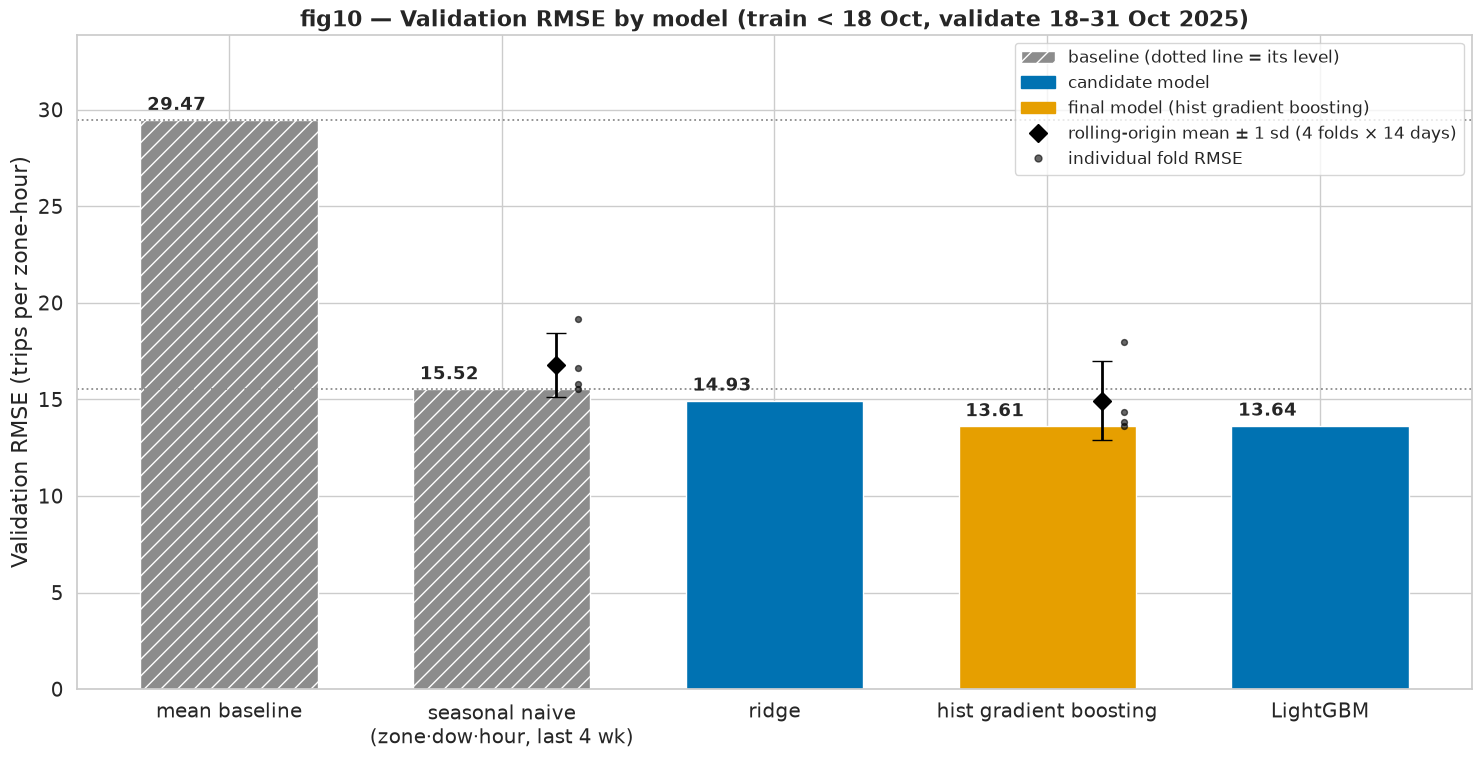

saved fig10_model_comparison.png: 2221×1140px


In [13]:
fig, ax = plt.subplots(figsize=(18, 8.5))
x = np.arange(len(results))
bar_colors, hatches = [], []
for r in results.itertuples():
    if r.kind == "baseline":
        bar_colors.append(C["grey"]); hatches.append("//")
    elif r.model == FINAL:
        bar_colors.append(C["orange"]); hatches.append("")
    else:
        bar_colors.append(C["blue"]); hatches.append("")
bars = ax.bar(x, results["rmse"], color=bar_colors, edgecolor="white", width=0.65)
for b, h in zip(bars, hatches):
    b.set_hatch(h)
for xi, v in zip(x, results["rmse"]):
    ax.text(xi - 0.3, v + 0.3, f"{v:.2f}", ha="left", va="bottom", fontsize=13, fontweight="bold")
for model, offset in [(FINAL, 0.2), (SNAIVE, 0.2)]:
    xi = results.index[results["model"] == model][0] + offset
    f = folds[folds["model"] == model]["rmse"]
    ax.errorbar(xi, fold_stats.loc[model, "mean"], yerr=fold_stats.loc[model, "std"], fmt="D", color=C["black"], ms=9, capsize=7, lw=2, zorder=5)
    ax.scatter(np.full(len(f), xi + 0.08), f, color=C["black"], s=18, alpha=0.6, zorder=5)
for label in BASELINES:
    v = results.loc[results["model"] == label, "rmse"].iloc[0]
    ax.axhline(v, color=C["grey"], ls=":", lw=1.3)
ax.set_xticks(x, results["model"])
ax.set_ylim(0, results["rmse"].max() * 1.15)
ax.set_ylabel("Validation RMSE (trips per zone-hour)")
ax.set_title(f"fig10 — Validation RMSE by model (train < {CUTOFF[8:]} Oct, validate {CUTOFF[8:]}–31 Oct 2025)")
ax.legend(
    handles=[
        Patch(facecolor=C["grey"], hatch="//", edgecolor="white", label="baseline (dotted line = its level)"),
        Patch(color=C["blue"], label="candidate model"),
        Patch(color=C["orange"], label=f"final model ({FINAL})"),
        plt.Line2D([], [], color=C["black"], marker="D", ls="", ms=9, label="rolling-origin mean ± 1 sd (4 folds × 14 days)"),
        plt.Line2D([], [], color=C["black"], marker="o", ls="", ms=5, alpha=0.6, label="individual fold RMSE"),
    ],
    loc="upper right",
    fontsize=12,
)
save(fig, "fig10_model_comparison")

r_final = results.set_index("model").loc[FINAL]
r_sn = results.set_index("model").loc[SNAIVE]
captions["fig10_model_comparison"] = (
    f"{FINAL} is the best model on the 18–31 Oct validation fortnight: RMSE {r_final.rmse:.2f} trips per zone-hour, versus "
    f"{r_sn.rmse:.2f} for the seasonal-naive baseline and {results.iloc[0].rmse:.2f} for the mean baseline "
    f"({100 * (1 - r_final.rmse / r_sn.rmse):.0f}% better than seasonal naive). Across 4 rolling-origin folds it averages "
    f"{fold_stats.loc[FINAL, 'mean']:.2f} ± {fold_stats.loc[FINAL, 'std']:.2f}, against {fold_stats.loc[SNAIVE, 'mean']:.2f} ± "
    f"{fold_stats.loc[SNAIVE, 'std']:.2f} for seasonal naive, so the advantage holds in every period tested, not just one."
)

## fig11 — Forecast vs actual

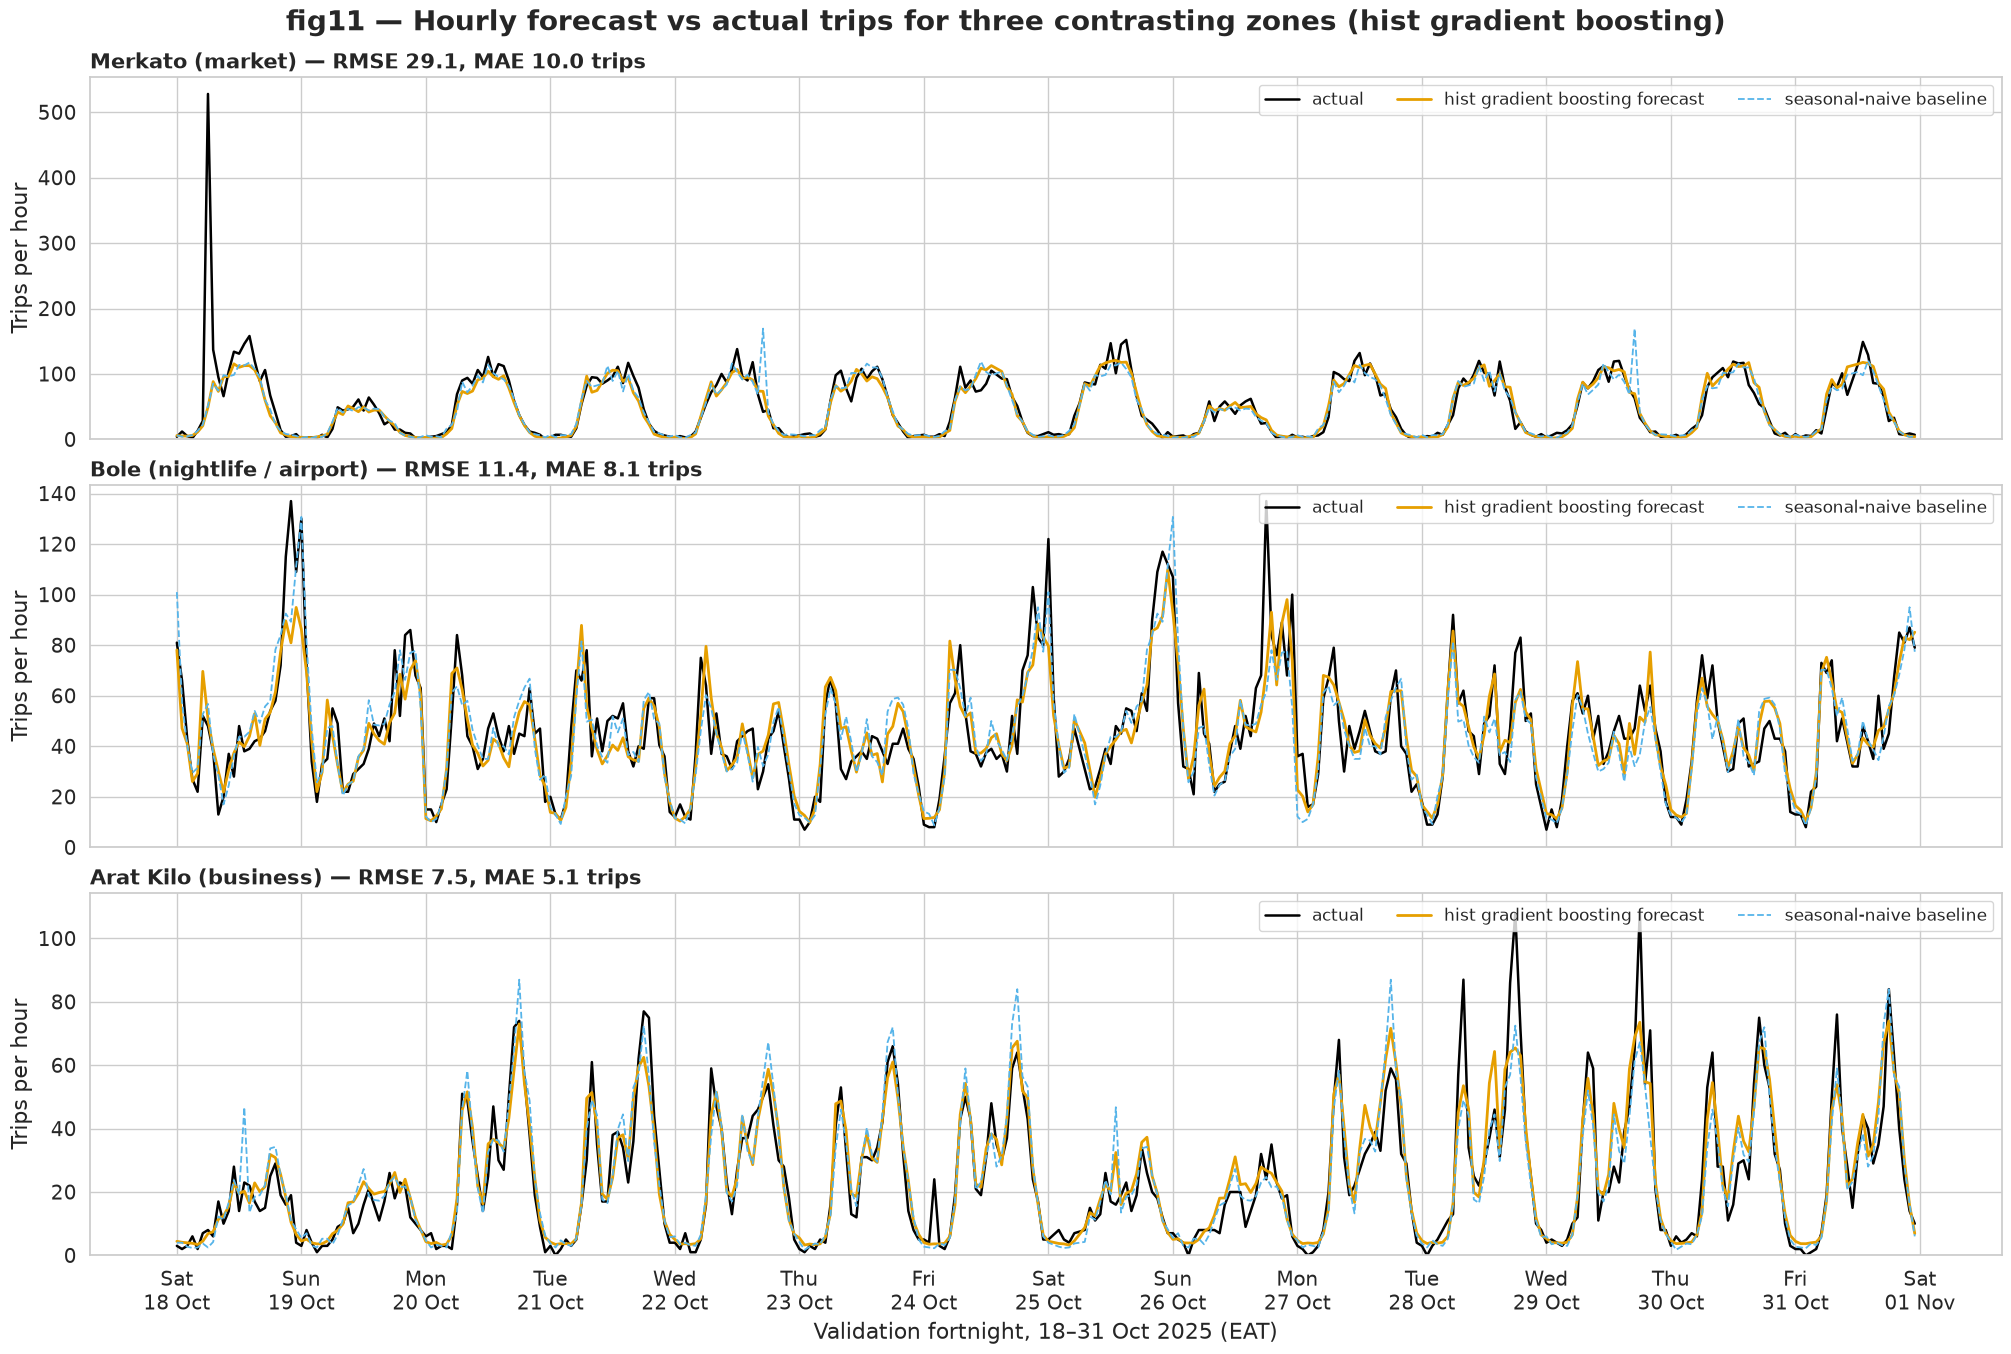

saved fig11_forecast_vs_actual.png: 3017×2032px


In [14]:
SHOW_ZONES = ["Merkato", "Bole", "Arat Kilo"]
vplot = va.assign(pred=preds[FINAL], snaive=preds[SNAIVE])
fig, axes = plt.subplots(len(SHOW_ZONES), 1, figsize=(20, 13), sharex=True, constrained_layout=True)
zone_err = {}
for ax, z in zip(axes, SHOW_ZONES):
    s = vplot[vplot["zone"] == z].sort_values("pickup_hour_eat")
    zone_err[z] = (M.rmse(s["trips"], s["pred"]), M.mae(s["trips"], s["pred"]))
    ax.plot(s["pickup_hour_eat"], s["trips"], color=C["black"], lw=1.8, label="actual")
    ax.plot(s["pickup_hour_eat"], s["pred"], color=C["orange"], lw=2, label=f"{FINAL} forecast")
    ax.plot(s["pickup_hour_eat"], s["snaive"], color=C["sky"], lw=1.3, ls="--", label="seasonal-naive baseline")
    ax.set_ylim(bottom=0)
    ax.set_ylabel("Trips per hour")
    ax.set_title(f"{z} ({ZONE_TYPE[z].replace('_', ' / ')}) — RMSE {zone_err[z][0]:.1f}, MAE {zone_err[z][1]:.1f} trips", loc="left", fontsize=15)
    ax.legend(loc="upper right", ncol=3, fontsize=12)
axes[-1].xaxis.set_major_locator(mdates.DayLocator(tz=vplot["pickup_hour_eat"].dt.tz))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d %b", tz=vplot["pickup_hour_eat"].dt.tz))
axes[-1].set_xlabel("Validation fortnight, 18–31 Oct 2025 (EAT)")
fig.suptitle(f"fig11 — Hourly forecast vs actual trips for three contrasting zones ({FINAL})", y=1.03)
save(fig, "fig11_forecast_vs_actual")

captions["fig11_forecast_vs_actual"] = (
    f"The {FINAL} forecast tracks the daily cycle and the weekday/weekend switch in all three zones "
    + "(" + "; ".join(f"{z} RMSE {e[0]:.1f}" for z, e in zone_err.items()) + " trips per hour). "
    "The largest misses are the sharpest one-off peaks, which neither the model nor the seasonal-naive baseline anticipates, "
    "consistent with unlisted events or bursts in the history."
)

## fig12 — Permutation feature importance

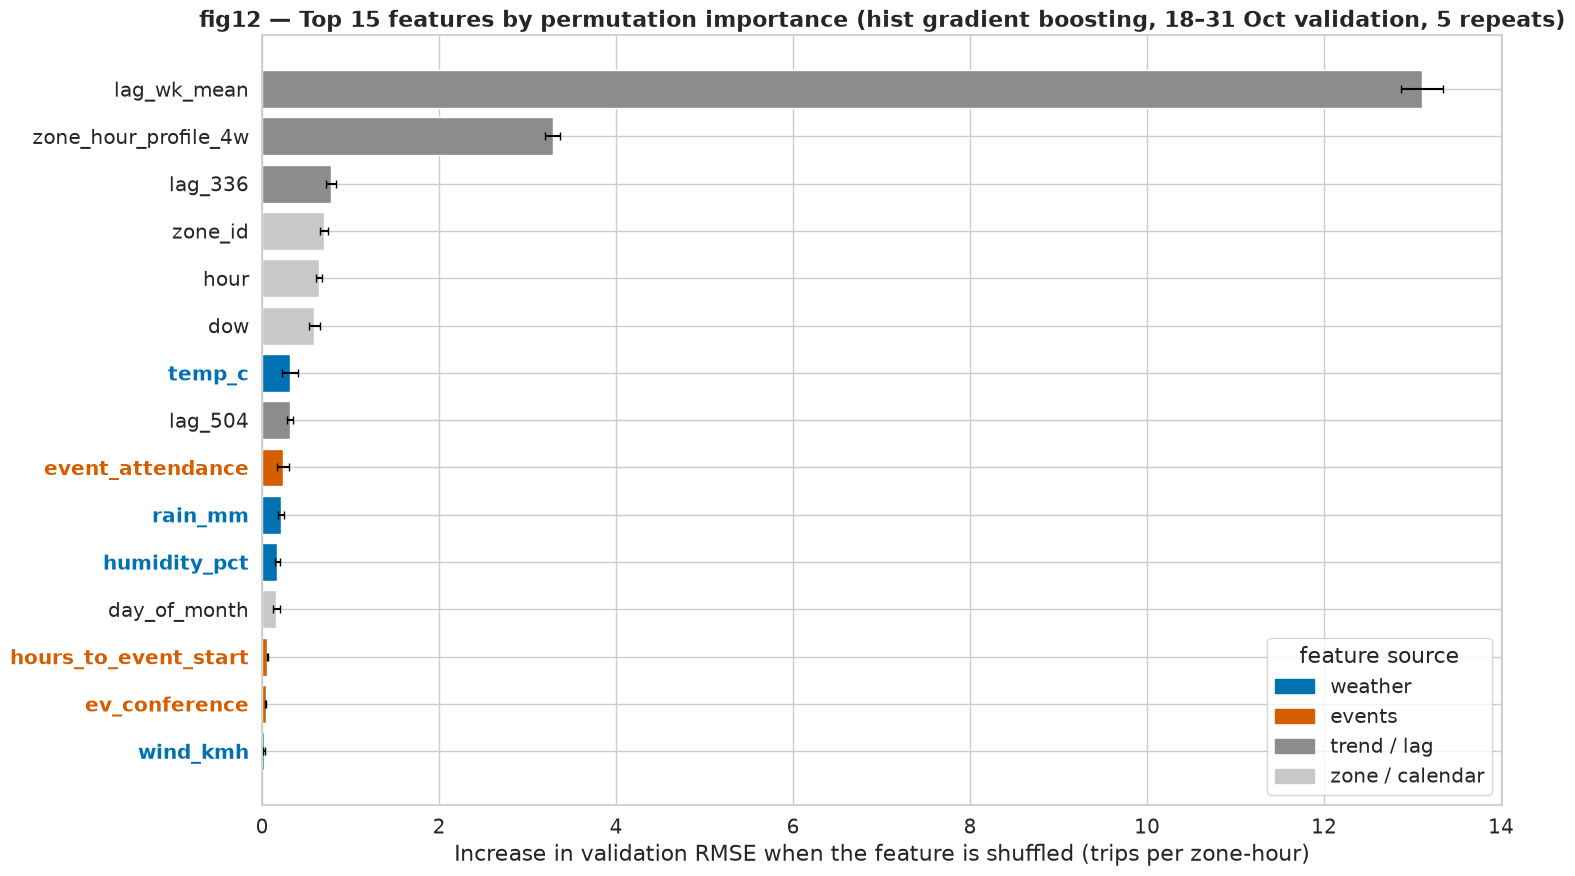

saved fig12_feature_importance.png: 2314×1312px


,feature,mean,std,group
9,lag_wk_mean,13.105,0.240,trend / lag
11,zone_hour_profile_4w,3.281,0.080,trend / lag
7,lag_336,0.780,0.057,trend / lag
0,zone_id,0.694,0.045,zone / calendar
1,hour,0.640,0.038,zone / calendar
2,dow,0.591,0.065,zone / calendar
12,temp_c,0.314,0.085,weather
8,lag_504,0.311,0.035,trend / lag
22,event_attendance,0.240,0.068,events
13,rain_mm,0.210,0.036,weather


In [15]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(
    fitted[FINAL], va[FEATS], va["trips"], scoring="neg_root_mean_squared_error",
    n_repeats=5, random_state=M.SEED, n_jobs=1,
)
imp = pd.DataFrame({"feature": FEATS, "mean": pi.importances_mean, "std": pi.importances_std})


def group_of(f: str) -> str:
    if f in M.WEATHER_FEATURES:
        return "weather"
    if f in M.EVENT_FEATURES:
        return "events"
    if f in M.TREND_LAG_FEATURES:
        return "trend / lag"
    return "zone / calendar"


GROUP_COLOR = {"weather": C["blue"], "events": C["vermillion"], "trend / lag": C["grey"], "zone / calendar": "#C8C8C8"}
imp["group"] = imp["feature"].map(group_of)
top = imp.sort_values("mean", ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(16, 10))
y = np.arange(len(top))
ax.barh(y, top["mean"].clip(lower=0), xerr=top["std"], color=top["group"].map(GROUP_COLOR), error_kw=dict(ecolor=C["black"], capsize=3))
ax.set_yticks(y, top["feature"])
for tick, g in zip(ax.get_yticklabels(), top["group"]):
    if g in ("weather", "events"):
        tick.set_color(GROUP_COLOR[g])
        tick.set_fontweight("bold")
ax.set_xlim(left=0)
ax.set_xlabel("Increase in validation RMSE when the feature is shuffled (trips per zone-hour)")
ax.legend(handles=[Patch(color=c, label=g) for g, c in GROUP_COLOR.items()], loc="lower right", title="feature source")
ax.set_title(f"fig12 — Top 15 features by permutation importance ({FINAL}, 18–31 Oct validation, 5 repeats)")
save(fig, "fig12_feature_importance")

best_w = imp[imp["group"] == "weather"].sort_values("mean", ascending=False).iloc[0]
best_e = imp[imp["group"] == "events"].sort_values("mean", ascending=False).iloc[0]
top1 = imp.sort_values("mean", ascending=False).iloc[0]
captions["fig12_feature_importance"] = (
    f"Recent demand level and the zone/hour structure carry most of the signal (top feature: `{top1.feature}`, +{top1['mean']:.2f} RMSE when shuffled). "
    f"Both joined tables still contribute: the strongest weather feature is `{best_w.feature}` (+{best_w['mean']:.2f}) and the strongest event feature "
    f"is `{best_e.feature}` (+{best_e['mean']:.2f}). These matter mainly in the rare rainy or event hours, where errors are largest."
)
imp.sort_values("mean", ascending=False).round(3).head(20)

## Write captions

In [16]:
ORDER = [
    "fig01_gaps_and_missingness",
    "fig02_before_after_cleaning",
    "fig03_demand_trend_with_holidays",
    "fig04_hour_by_weekday_heatmap",
    "fig05_zone_profiles",
    "fig06_weather_timezone_check",
    "fig07_rain_effect",
    "fig08_event_study",
    "fig09_holiday_effects",
    "fig10_model_comparison",
    "fig11_forecast_vs_actual",
    "fig12_feature_importance",
]
assert set(ORDER) == set(captions), set(ORDER) ^ set(captions)
lines = [
    "# Figure captions (Deliverable C)",
    "",
    "Generated by `notebooks/03_visualizations.ipynb`; every number below is computed in that notebook.",
    "",
]
for name in ORDER:
    assert (FIG / f"{name}.png").exists(), name
    lines += [f"## {name}.png", "", captions[name], ""]
(FIG / "figure_captions.md").write_text("\n".join(lines), encoding="utf-8")
print("\n".join(lines))

# Figure captions (Deliverable C)

Generated by `notebooks/03_visualizations.ipynb`; every number below is computed in that notebook.

## fig01_gaps_and_missingness.png

Data problems are concentrated in a few columns. The worst is `expected_attendance` in events_calendar.csv (32.7% of rows), and every other trip-table column is below 2.0%. The timeline separates three kinds of gap: one platform outage (42 h on 12 May, 13 May) hitting every zone, Ayat having no rows until it launched on 15 Mar, and scattered single missing hours. None of these gaps are filled with zero demand.

## fig02_before_after_cleaning.png

Cleaning changes the picture for three variables. 353 temperature readings in the 50–80 range were Fahrenheit and become °C; 76 rain readings coded −9999 pulled monthly mean rain as low as -187 mm/h and are interpolated instead; 1.0% blank and 0.8% negative (−1) trip counts are imputed. Without these fixes the rain and temperature features would be meaningless.

## fig03_deman